In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

In [11]:
data_path = '../../data/interim/'

In [17]:
plt.rcParams['font.family'] = 'Malgun Gothic' # 맥 유저라면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [16]:
data_path = '../../data/interim/'
events_df = pd.read_csv(data_path + 'hackle_events_preprocessed.csv')

In [18]:
events_df['event_datetime'] = pd.to_datetime(events_df['event_datetime'])
events_df = events_df.sort_values(by=['session_id', 'event_datetime']).reset_index(drop=True)
print(f"총 이벤트 로그 수: {len(events_df):,}건")
display(events_df.head())

총 이벤트 로그 수: 11,441,319건


,event_id,event_datetime,event_key,session_id,item_name,page_name,friend_count,votes_count,heart_balance,question_id
0,584085d4-95a9-47e4-a00b-070c433d0996,2023-07-21 14:23:33,launch_app,000137bc-80de-4bb5-b61d-df7f217a4501,NaN,NaN,NaN,NaN,NaN,NaN
1,ac63bbaa-a96e-49ce-8980-878fa1cb50de,2023-07-21 14:23:33,$session_start,000137bc-80de-4bb5-b61d-df7f217a4501,NaN,NaN,NaN,NaN,NaN,NaN
2,1a7d09d7-8760-4c01-9e47-532c3bd93d7c,2023-07-22 23:30:09,launch_app,00025EE1-BA46-4853-8FDD-B991FABA328F,NaN,NaN,52.0,68.0,210.0,NaN
3,e0c8259f-c343-4c3c-bf29-d3f9f57bb01b,2023-07-22 23:30:09,$session_start,00025EE1-BA46-4853-8FDD-B991FABA328F,NaN,NaN,52.0,68.0,210.0,NaN
4,0b7e4def-fb8d-4435-be8e-ad1124666734,2023-07-22 23:30:31,launch_app,00025EE1-BA46-4853-8FDD-B991FABA328F,NaN,NaN,52.0,68.0,210.0,NaN


C:\Users\andan\AppData\Local\Temp\ipykernel_2032\3669528370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_events.values, y=top_events.index, ax=axes[0], palette='viridis')
C:\Users\andan\AppData\Local\Temp\ipykernel_2032\3669528370.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pages.values, y=top_pages.index, ax=axes[1], palette='magma')


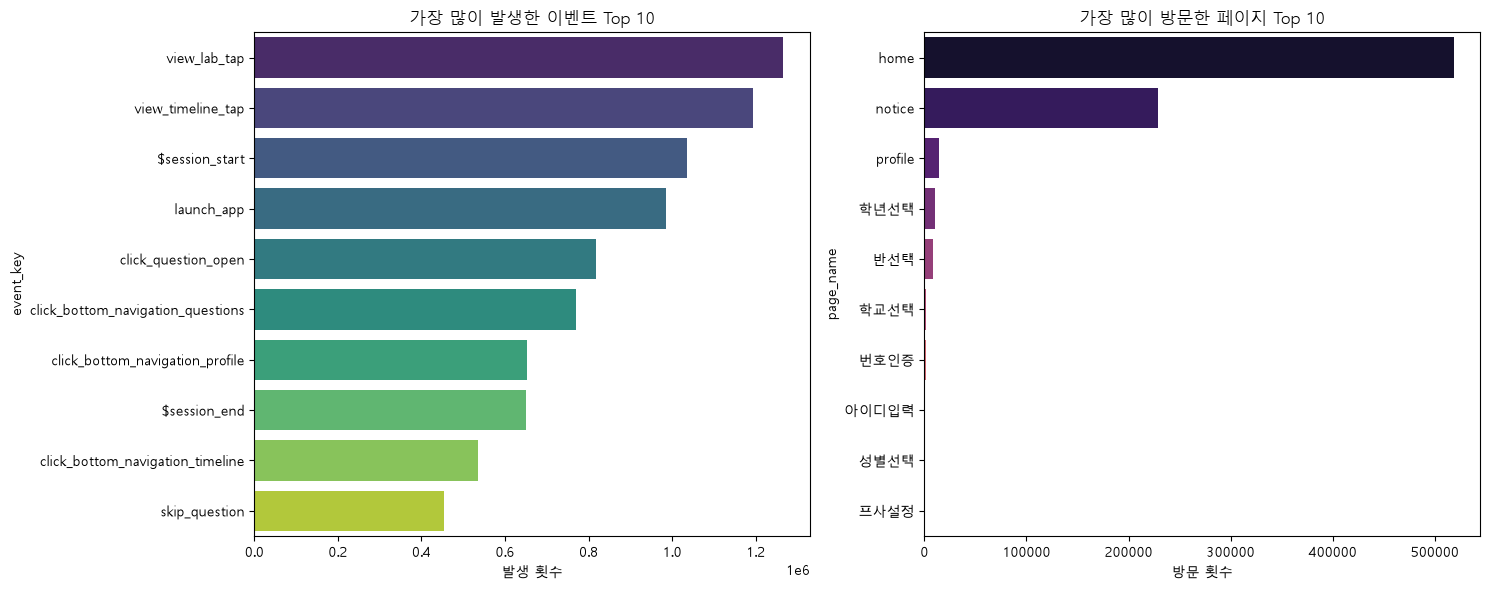

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 가장 많이 발생한 이벤트(행동) Top 10
top_events = events_df['event_key'].value_counts().head(10)
sns.barplot(x=top_events.values, y=top_events.index, ax=axes[0], palette='viridis')
axes[0].set_title('가장 많이 발생한 이벤트 Top 10')
axes[0].set_xlabel('발생 횟수')

page_data = events_df.dropna(subset=['page_name'])
top_pages = page_data['page_name'].value_counts().head(10)
sns.barplot(x=top_pages.values, y=top_pages.index, ax=axes[1], palette='magma')
axes[1].set_title('가장 많이 방문한 페이지 Top 10')
axes[1].set_xlabel('방문 횟수')

plt.tight_layout()
plt.show()

In [21]:
# 1. 이벤트 Top 10 표 형식으로 변환
top_events_df = top_events.reset_index()
top_events_df.columns = ['이벤트명 (event_key)', '발생 횟수']

# 2. 페이지 Top 10 표 형식으로 변환
top_pages_df = top_pages.reset_index()
top_pages_df.columns = ['페이지명 (page_name)', '방문 횟수']

# 3. 천 단위 콤마(,)를 적용하여 깔끔하게 출력 (Jupyter notebook 환경 최적화)
print("가장 많이 발생한 이벤트 Top 10 ===")
display(top_events_df.style.format({'발생 횟수': '{:,}'}))

print("\가장 많이 방문한 페이지 Top 10 ===")
display(top_pages_df.style.format({'방문 횟수': '{:,}'}))

가장 많이 발생한 이벤트 Top 10 ===


,이벤트명 (event_key),발생 횟수
0,view_lab_tap,"1,266,665"
1,view_timeline_tap,"1,194,508"
2,$session_start,"1,036,852"
3,launch_app,"986,388"
4,click_question_open,"816,801"
5,click_bottom_navigation_questions,"769,163"
6,click_bottom_navigation_profile,"653,507"
7,$session_end,"649,658"
8,click_bottom_navigation_timeline,"536,051"
9,skip_question,"454,981"


\가장 많이 방문한 페이지 Top 10 ===


,페이지명 (page_name),방문 횟수
0,home,"518,348"
1,notice,"229,358"
2,profile,"14,627"
3,학년선택,"10,714"
4,반선택,"8,592"
5,학교선택,"1,904"
6,번호인증,"1,246"
7,아이디입력,"1,072"
8,성별선택,"1,057"
9,프사설정,"1,020"


In [22]:
import pandas as pd

# 1. 전체 이벤트 및 페이지 발생 횟수 집계
all_events_df = events_df['event_key'].value_counts().reset_index()
all_events_df.columns = ['이벤트명 (event_key)', '발생 횟수']

all_pages_df = events_df['page_name'].dropna().value_counts().reset_index()
all_pages_df.columns = ['페이지명 (page_name)', '방문 횟수']

print(f"✅ 총 {len(all_events_df)}개의 고유 이벤트가 존재합니다.")
print(f"✅ 총 {len(all_pages_df)}개의 고유 페이지가 존재합니다.\n")

# 2. pandas 출력 제한을 해제하여 전체 목록 표시 (이 블록 안에서만 적용됨)
with pd.option_context('display.max_rows', None):
    print("=== 📋 전체 이벤트 상세 목록 ===")
    display(all_events_df.style.format({'발생 횟수': '{:,}'}))
    
    print("\n=== 📋 전체 페이지 상세 목록 ===")
    display(all_pages_df.style.format({'방문 횟수': '{:,}'}))

✅ 총 44개의 고유 이벤트가 존재합니다.
✅ 총 12개의 고유 페이지가 존재합니다.

=== 📋 전체 이벤트 상세 목록 ===


,이벤트명 (event_key),발생 횟수
0,view_lab_tap,"1,266,665"
1,view_timeline_tap,"1,194,508"
2,$session_start,"1,036,852"
3,launch_app,"986,388"
4,click_question_open,"816,801"
5,click_bottom_navigation_questions,"769,163"
6,click_bottom_navigation_profile,"653,507"
7,$session_end,"649,658"
8,click_bottom_navigation_timeline,"536,051"
9,skip_question,"454,981"



=== 📋 전체 페이지 상세 목록 ===


,페이지명 (page_name),방문 횟수
0,home,"518,348"
1,notice,"229,358"
2,profile,"14,627"
3,학년선택,"10,714"
4,반선택,"8,592"
5,학교선택,"1,904"
6,번호인증,"1,246"
7,아이디입력,"1,072"
8,성별선택,"1,057"
9,프사설정,"1,020"


In [12]:
friend_req_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed.csv')
contacts_df = pd.read_csv(data_path + 'accounts_user_contacts_preprocessed.csv')
vote_df = pd.read_csv(data_path + 'polls_questionpiece_preprocessed.csv')

In [13]:
req_status_counts = friend_req_df['status'].value_counts(normalize=True) * 100
print("--- 친구 요청 상태별 비율(%) ---")
print(req_status_counts)

--- 친구 요청 상태별 비율(%) ---
status
A    75.105124
P    22.969428
R     1.925448
Name: proportion, dtype: float64


In [14]:
accepted_friends = friend_req_df[friend_req_df['status'] == 'A'] # A: Accepted 가정
friends_list = pd.concat([accepted_friends['send_user_id'], accepted_friends['receive_user_id']])

user_friend_counts = friends_list.value_counts().reset_index()
user_friend_counts.columns = ['user_id', 'friend_count']

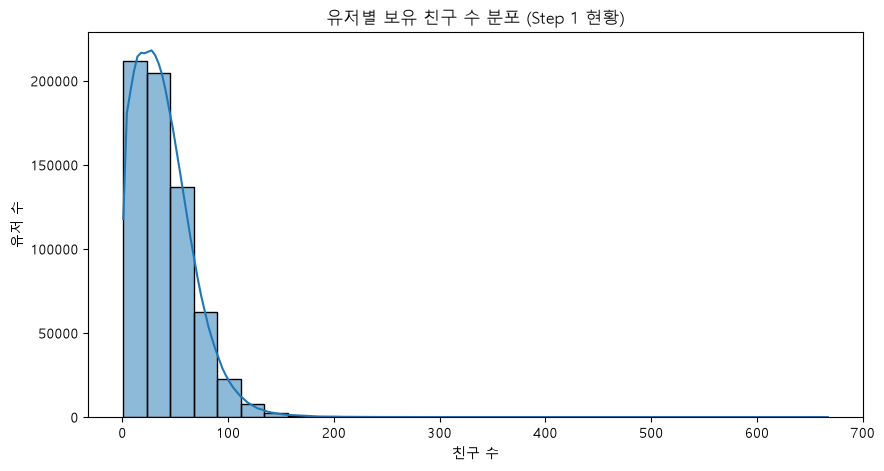

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(user_friend_counts['friend_count'], bins=30, kde=True)
plt.title('유저별 보유 친구 수 분포 (Step 1 현황)')
plt.xlabel('친구 수')
plt.ylabel('유저 수')
plt.show()

In [2]:
# is_skipped와 is_voted 컬럼에 어떤 값들이 들어있는지, 결측치(NaN)는 없는지 확인
print("=== is_skipped 값 분포 ===")
print(piece_df['is_skipped'].value_counts(dropna=False))

print("\n=== is_voted 값 분포 ===")
print(piece_df['is_voted'].value_counts(dropna=False))

=== is_skipped 값 분포 ===
is_skipped
0    1264349
Name: count, dtype: int64

=== is_voted 값 분포 ===
is_voted
1    1217560
0      46789
Name: count, dtype: int64


In [3]:
piece_df.describe()

,id,is_voted,question_id,is_skipped
count,1.264349e+06,1.264349e+06,1.264349e+06,1264349.0
mean,7.653767e+07,9.629936e-01,7.128788e+02,0.0
std,5.910501e+07,1.887775e-01,6.700039e+02,0.0
min,9.984580e+05,0.000000e+00,9.900000e+01,0.0
25%,2.025583e+07,1.000000e+00,2.780000e+02,0.0
50%,6.840611e+07,1.000000e+00,4.770000e+02,0.0
75%,1.212145e+08,1.000000e+00,9.810000e+02,0.0
max,2.083852e+08,1.000000e+00,5.133000e+03,0.0


In [4]:
import pandas as pd

# 1. 데이터 로드
data_path = '../../data/interim/'
piece_df = pd.read_csv(data_path + 'polls_questionpiece_preprocessed.csv')
question_df = pd.read_csv(data_path + 'polls_question_preprocessed.csv')

# 2. is_voted를 정수형(1, 0)으로 강제 변환 (결측치는 0으로 간주)
piece_df['is_voted'] = piece_df['is_voted'].fillna(0).astype(int)

# 3. 질문 ID(question_id)별 집계: 전체 할당(노출) 수와 실제 투표 수
q_stats = piece_df.groupby('question_id').agg(
    total_exposed=('id', 'count'),       # 질문이 유저에게 노출된 총 횟수
    voted_count=('is_voted', 'sum')      # 실제 투표로 이어진 횟수
).reset_index()

# 4. 미투표(이탈) 횟수 및 이탈률 계산
q_stats['unvoted_count'] = q_stats['total_exposed'] - q_stats['voted_count']
q_stats['drop_rate'] = (q_stats['unvoted_count'] / q_stats['total_exposed']) * 100

# 5. 질문 내용 텍스트 결합
q_analysis_df = pd.merge(q_stats, question_df[['id', 'question_text']], 
                         left_on='question_id', right_on='id', how='inner')

# 6. 신뢰도를 위해 충분히 노출된 질문(예: 50회 이상)만 필터링
valid_q_df = q_analysis_df[q_analysis_df['total_exposed'] >= 50]

# 7. 이탈률(미투표율) 기준 Top 10 추출
worst_questions = valid_q_df.sort_values(by='drop_rate', ascending=False).head(10)
best_questions = valid_q_df.sort_values(by='drop_rate', ascending=True).head(10)

# --- 결과 출력 ---
print("=== 🚨 유저들이 가장 많이 이탈한(투표하지 않은) 질문 Top 10 ===")
display(worst_questions[['question_text', 'total_exposed', 'unvoted_count', 'drop_rate']].style.format({'drop_rate': '{:.2f}%'}))

print("\n=== ✨ 유저들이 가장 적극적으로 참여한 질문 Top 10 ===")
display(best_questions[['question_text', 'total_exposed', 'voted_count', 'drop_rate']].style.format({'drop_rate': '{:.2f}%'}))

=== 🚨 유저들이 가장 많이 이탈한(투표하지 않은) 질문 Top 10 ===


,question_text,total_exposed,unvoted_count,drop_rate
1741,침대에 가장 오랜 시간 있을 것 같은 사람,50,13,26.00%
1815,집에서 가장 애교가 많을 것 같은 사람은?,53,13,24.53%
2567,만약 사업을 한다면 성공할 것 같은 사람,50,12,24.00%
2421,버스에서 턱걸이 할 것 같은 사람은?,56,13,23.21%
2514,모기 많이 물릴 것 같은 사람은?,50,11,22.00%
2834,과제 당일 시작할 것 같은 사람은?,50,11,22.00%
1557,후배와 친하게 지낼 것 같은 사람은?,50,11,22.00%
2676,노는데 진심인 사람,56,12,21.43%
2294,손님 응대를 가장 잘 할 것 같은 사람은?,50,10,20.00%
2200,알약 한번에 5개씩 삼킬것 같은 사람은?,51,10,19.61%



=== ✨ 유저들이 가장 적극적으로 참여한 질문 Top 10 ===


,question_text,total_exposed,voted_count,drop_rate
134,힘든 일이 있을때 제일 의지가 될것 같은 사람은?,1611,1595,0.99%
131,같이 스몰토크 하다가 밤을 샐 것 같은 사람은?,1752,1734,1.03%
47,본인과 가장 어울리는 옷을 입는 사람은?,1845,1826,1.03%
333,매일 탕후루 하나씩 먹을 것 같은 사람은?,1552,1536,1.03%
152,상견례 프리패스상인 사람은?,1794,1774,1.11%
53,숨겨진 댄싱 머신이라고 생각하는 사람은?,1955,1933,1.13%
389,솔직한 모습이 멋진 사람은?,1510,1493,1.13%
221,함께한 추억이 가장 많은 사람은?,1614,1595,1.18%
228,누가 잡아가도 다 헤쳐나올 수 있을 것 같은 사람은?,1663,1643,1.20%
17,대학가서 용될것 같은 사람은?,1733,1712,1.21%


In [7]:
import matplotlib.pyplot as plt

# 윈도우용 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

C:\Users\andan\AppData\Local\Temp\ipykernel_21744\4235149391.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_engagement, x='friend_group', y='set_count', palette='Blues_d')


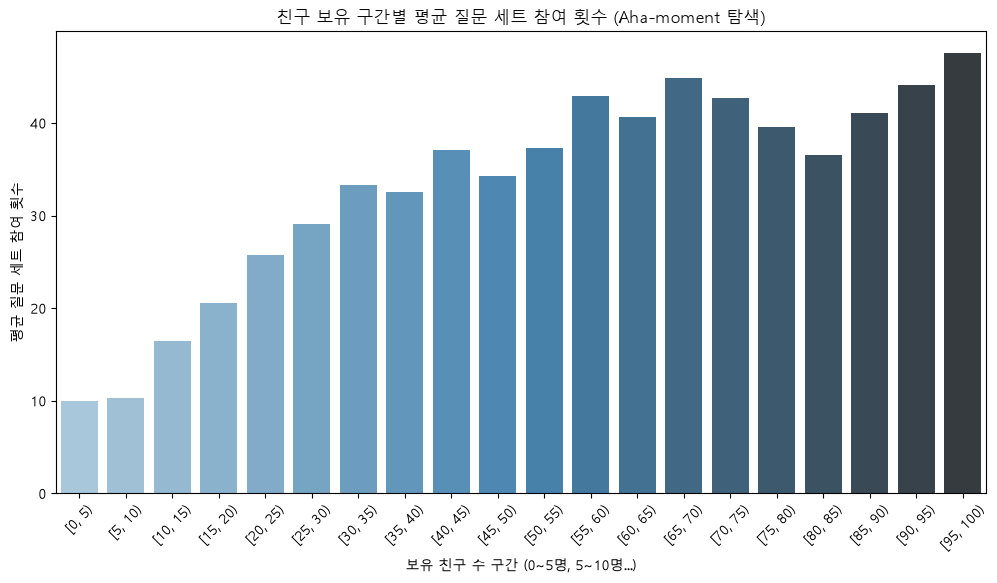

✅ 친구 수와 질문 세트 참여 횟수의 상관계수: 0.273


In [8]:
# 데이터 로드
data_path = '../../data/interim/'
friend_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed.csv')

# piece_df 대신 user_id가 존재하는 questionset_df 활용
set_df = pd.read_csv(data_path + 'polls_questionset_preprocessed.csv')

# 1. 유저별 친구 수 계산 (수락된 상태 'A' 기준)
accepted = friend_df[friend_df['status'] == 'A']
friends = pd.concat([accepted['send_user_id'], accepted['receive_user_id']])
friend_counts = friends.value_counts().reset_index()
friend_counts.columns = ['user_id', 'friend_count']

# 2. 유저별 질문 세트(투표 묶음) 참여 횟수 계산
# user_id별로 생성된 세트 수를 카운트하여 앱 참여도로 활용
user_sets = set_df.groupby('user_id').size().reset_index(name='set_count')

# 3. 데이터 결합
aha_df = pd.merge(friend_counts, user_sets, on='user_id', how='inner')

# 4. 친구 수 구간(Binning)별 평균 질문 세트 참여 횟수 계산
aha_df['friend_group'] = pd.cut(aha_df['friend_count'], bins=range(0, 105, 5), right=False)
group_engagement = aha_df.groupby('friend_group')['set_count'].mean().reset_index()

# 5. 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=group_engagement, x='friend_group', y='set_count', palette='Blues_d')
plt.title('친구 보유 구간별 평균 질문 세트 참여 횟수 (Aha-moment 탐색)')
plt.xlabel('보유 친구 수 구간 (0~5명, 5~10명...)')
plt.ylabel('평균 질문 세트 참여 횟수')
plt.xticks(rotation=45)
plt.show()

# 6. 상관계수 확인
corr = aha_df['friend_count'].corr(aha_df['set_count'])
print(f"✅ 친구 수와 질문 세트 참여 횟수의 상관계수: {corr:.3f}")

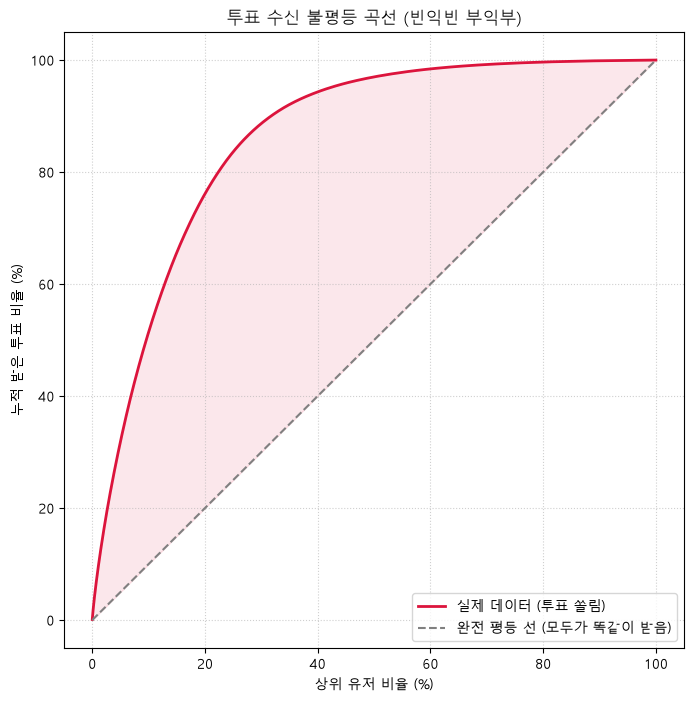

🚨 상위 10% 유저가 전체 투표의 51.4%를 독식하고 있습니다.
🚨 상위 20% 유저가 전체 투표의 76.1%를 차지하고 있습니다.


In [9]:
# 투표 기록 데이터 로드
record_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')

# 1. 유저별 받은 투표 수 집계
vote_received = record_df['chosen_user_id'].value_counts().reset_index()
vote_received.columns = ['user_id', 'received_count']

# 2. 많이 받은 순으로 정렬하여 누적 비율 계산
vote_received = vote_received.sort_values(by='received_count', ascending=False).reset_index(drop=True)

# 누적 투표 수 및 퍼센트 계산
vote_received['cumulative_votes'] = vote_received['received_count'].cumsum()
total_votes = vote_received['received_count'].sum()
vote_received['cumulative_votes_pct'] = (vote_received['cumulative_votes'] / total_votes) * 100

# 상위 유저 퍼센트 계산
vote_received['user_rank'] = range(1, len(vote_received) + 1)
vote_received['user_pct'] = (vote_received['user_rank'] / len(vote_received)) * 100

# 3. 로렌츠 곡선 (불평등도) 시각화
plt.figure(figsize=(8, 8))
plt.plot(vote_received['user_pct'], vote_received['cumulative_votes_pct'], color='crimson', linewidth=2, label='실제 데이터 (투표 쏠림)')
plt.plot([0, 100], [0, 100], color='gray', linestyle='--', label='완전 평등 선 (모두가 똑같이 받음)')
plt.fill_between(vote_received['user_pct'], vote_received['user_pct'], vote_received['cumulative_votes_pct'], color='crimson', alpha=0.1)

plt.title('투표 수신 불평등 곡선 (빈익빈 부익부)')
plt.xlabel('상위 유저 비율 (%)')
plt.ylabel('누적 받은 투표 비율 (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 4. 핵심 지표 출력
top_10_pct = vote_received[vote_received['user_pct'] <= 10]['received_count'].sum() / total_votes * 100
top_20_pct = vote_received[vote_received['user_pct'] <= 20]['received_count'].sum() / total_votes * 100

print(f"🚨 상위 10% 유저가 전체 투표의 {top_10_pct:.1f}%를 독식하고 있습니다.")
print(f"🚨 상위 20% 유저가 전체 투표의 {top_20_pct:.1f}%를 차지하고 있습니다.")

In [1]:
import pandas as pd

data_path = '../../data/interim/'

# 1. 전체 유저 데이터 로드
user_df = pd.read_csv(data_path + 'accounts_user_preprocessed.csv')

# 2. 질문 세트(투표 묶음) 데이터 로드
questionset_df = pd.read_csv(data_path + 'polls_questionset_preprocessed.csv')

# 3. 고유 유저 수 카운트
total_users = user_df['id'].nunique()
sample_users = questionset_df['user_id'].nunique()

# 4. 결과 출력
print("=== 📊 유저 데이터 규모 확인 ===")
print(f"✅ 전체 가입 유저 수 (accounts_user 기준): {total_users:,}명")
print(f"✅ 투표 표본 유저 수 (polls_questionset 기준): {sample_users:,}명")

# (참고) 만약 두 데이터 간의 교집합을 보고 싶다면 아래 주석을 해제하세요.
# common_users = len(set(user_df['id']).intersection(set(questionset_df['user_id'])))
# print(f"✅ 두 테이블에 모두 존재하는 유저 수: {common_users:,}명")|

=== 📊 유저 데이터 규모 확인 ===
✅ 전체 가입 유저 수 (accounts_user 기준): 677,081명
✅ 투표 표본 유저 수 (polls_questionset 기준): 4,965명


In [3]:
import pandas as pd

# 데이터 경로 (필요시 수정)
data_path = '../../data/interim/'

# accounts_user와 polls_questionset 데이터를 모두 명시적으로 로드
user_df = pd.read_csv(data_path + 'accounts_user_preprocessed.csv')
set_df = pd.read_csv(data_path + 'polls_questionset_preprocessed.csv') # <- 이 줄이 추가되었습니다!

# 시간 데이터 타입 변환
user_df['created_at'] = pd.to_datetime(user_df['created_at'])
set_df['created_at'] = pd.to_datetime(set_df['created_at'])

print("=== 📅 데이터 기간 확인 ===")
print(f"가입 유저(accounts_user) 기간: {user_df['created_at'].min()} ~ {user_df['created_at'].max()}")
print(f"투표 세트(polls_questionset) 기간: {set_df['created_at'].min()} ~ {set_df['created_at'].max()}")

=== 📅 데이터 기간 확인 ===
가입 유저(accounts_user) 기간: 2023-03-29 05:18:56.162368 ~ 2024-05-09 08:31:17.710824
투표 세트(polls_questionset) 기간: 2023-04-28 12:28:07 ~ 2024-05-07 11:32:30


C:\Users\andan\AppData\Local\Temp\ipykernel_21124\1074979863.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_engagement, x='friend_group', y='set_count', palette='Blues_d')


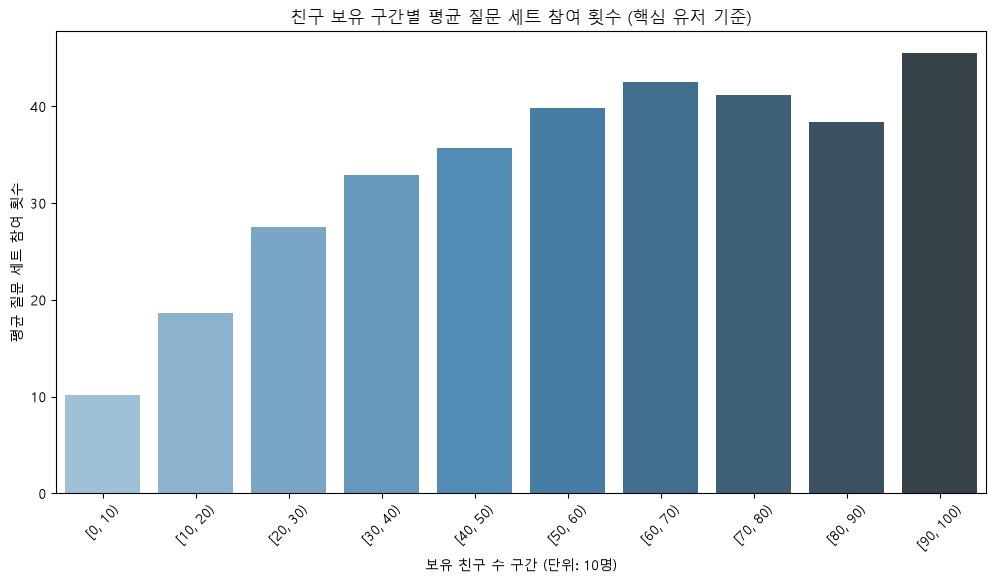

=== 📊 분석 대상 핵심 유저 수: 4,940명 ===
✅ 친구 수와 투표 참여도의 상관계수: 0.273


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 한글 폰트 설정 (윈도우 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
data_path = '../../data/interim/'
friend_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed.csv')
set_df = pd.read_csv(data_path + 'polls_questionset_preprocessed.csv')

# 3. 유저별 친구 수 계산 (수락 완료된 'A' 상태 기준)
accepted = friend_df[friend_df['status'] == 'A']
friends = pd.concat([accepted['send_user_id'], accepted['receive_user_id']])
friend_counts = friends.value_counts().reset_index()
friend_counts.columns = ['user_id', 'friend_count']

# 4. 유저별 투표 세트(묶음) 참여 횟수 계산
user_sets = set_df.groupby('user_id').size().reset_index(name='set_count')

# 5. 핵심 표본 필터링 및 병합 (inner join을 통해 투표 세트가 있는 유저만 남김)
aha_df = pd.merge(friend_counts, user_sets, on='user_id', how='inner')

# 6. 친구 수 10명 단위 구간(Binning) 설정
aha_df['friend_group'] = pd.cut(aha_df['friend_count'], bins=range(0, 110, 10), right=False)
group_engagement = aha_df.groupby('friend_group')['set_count'].mean().reset_index()

# 7. Aha-moment 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=group_engagement, x='friend_group', y='set_count', palette='Blues_d')
plt.title('친구 보유 구간별 평균 질문 세트 참여 횟수 (핵심 유저 기준)')
plt.xlabel('보유 친구 수 구간 (단위: 10명)')
plt.ylabel('평균 질문 세트 참여 횟수')
plt.xticks(rotation=45)
plt.show()

# 8. 통계 수치 확인
print(f"=== 📊 분석 대상 핵심 유저 수: {len(aha_df):,}명 ===")
print(f"✅ 친구 수와 투표 참여도의 상관계수: {aha_df['friend_count'].corr(aha_df['set_count']):.3f}")

In [2]:
import pandas as pd

# 1. 데이터 로드 (경로는 상황에 맞게 수정)
data_path = '../../data/interim/'
user_df = pd.read_csv(data_path + 'accounts_user_preprocessed.csv')
friend_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed.csv')
set_df = pd.read_csv(data_path + 'polls_questionset_preprocessed.csv')

# 2. 전체 유저별 친구 수 계산 (수락 'A' 기준)
accepted = friend_df[friend_df['status'] == 'A']
friends = pd.concat([accepted['send_user_id'], accepted['receive_user_id']])
friend_counts = friends.value_counts().reset_index()
friend_counts.columns = ['id', 'friend_count'] # accounts_user의 id와 맞춤

# 3. 전체 가입 유저에 친구 수 매핑 (친구가 없으면 0으로 처리)
user_base = pd.merge(user_df[['id']], friend_counts, on='id', how='left')
user_base['friend_count'] = user_base['friend_count'].fillna(0)

# 4. 투표 경험 그룹(4,965명)과 미경험 그룹 분리
voted_users = set_df['user_id'].unique()
user_base['has_voted'] = user_base['id'].isin(voted_users)

# 5. 그룹별 통계 비교
# 그룹 분리
voted_group = user_base[user_base['has_voted'] == True]
non_voted_group = user_base[user_base['has_voted'] == False]

# '친구 0명' 유저 비율 계산
zero_friend_voted = (len(voted_group[voted_group['friend_count'] == 0]) / len(voted_group)) * 100
zero_friend_non_voted = (len(non_voted_group[non_voted_group['friend_count'] == 0]) / len(non_voted_group)) * 100

print("=== 🚨 투표 그룹 vs 미투표 그룹: 친구 네트워크 비교 ===")
print(f"[투표 경험 유저 ({len(voted_group):,}명)]")
print(f" - 평균 친구 수: {voted_group['friend_count'].mean():.1f}명")
print(f" - 친구가 0명인 유저 비율: {zero_friend_voted:.1f}%\n")

print(f"[투표 미경험 유저 ({len(non_voted_group):,}명)]")
print(f" - 평균 친구 수: {non_voted_group['friend_count'].mean():.1f}명")
print(f" - 친구가 0명인 유저 비율: {zero_friend_non_voted:.1f}%")

=== 🚨 투표 그룹 vs 미투표 그룹: 친구 네트워크 비교 ===
[투표 경험 유저 (4,965명)]
 - 평균 친구 수: 44.6명
 - 친구가 0명인 유저 비율: 0.5%

[투표 미경험 유저 (672,116명)]
 - 평균 친구 수: 38.0명
 - 친구가 0명인 유저 비율: 4.0%


In [ ]:
import pandas as pd

data_path = '../../data/interim/' # 예시 경로
questionset_df = pd.read_csv(data_path + 'polls_questionset_preprocessed.csv')
userquestionrecord_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')
paymenthistory_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed.csv')

set_users = questionset_df['user_id'].nunique()

voted_users = userquestionrecord_df['user_id'].nunique()


paid_users = paymenthistory_df['user_id'].nunique()

print(f"1단계 (투표 세트 할당): {set_users:,}명")
print(f"2단계 (투표 실제 완료): {voted_users:,}명 (전환율: {voted_users/set_users*100:.1f}%)")
print(f"3단계 (최종 결제 완료): {paid_users:,}명 (전환율: {paid_users/voted_users*100:.1f}%)")

1단계 (투표 세트 할당): 4,965명
2단계 (투표 실제 완료): 4,849명 (전환율: 97.7%)
3단계 (최종 결제 완료): 59,192명 (전환율: 1220.7%)


In [ ]:
import pandas as pd

# 1. 투표를 1회 이상 '받은' 유저 (Receiver) 리스트 추출
# chosen_user_id에서 결측치(NaN) 제거 후 고유값 카운트
received_users_list = userquestionrecord_df['chosen_user_id'].dropna().unique()
received_users_count = len(received_users_list)

# 2. 투표를 받은 유저 집단 안에서, 실제로 상점에서 '결제'를 한 유저 필터링
valid_payments = paymenthistory_df[paymenthistory_df['user_id'].isin(received_users_list)]
paid_receivers_count = valid_payments['user_id'].nunique()

# 3. BM 퍼널 결과 출력
print(f"1단계 (투표를 1회 이상 받은 유저): {received_users_count:,}명")
print(f"2단계 (수신 후 호기심에 결제한 유저): {paid_receivers_count:,}명")

if received_users_count > 0:
    print(f"최종 수신자 결제 전환율: {paid_receivers_count / received_users_count * 100:.1f}%")

--- 🎯 핵심 BM 전환율 (수신자 기준) ---
1단계 (투표를 1회 이상 받은 유저): 15,426명
2단계 (수신 후 호기심에 결제한 유저): 1,213명
👉 최종 수신자 결제 전환율: 7.9%


In [ ]:
import pandas as pd

# 1. 전체 집합 정의
# (데이터 로드는 완료되었다고 가정)
all_paid_users = set(paymenthistory_df['user_id'].unique())
received_users = set(userquestionrecord_df['chosen_user_id'].dropna().unique())
all_registered_users = set(user_df['id'].unique())

# 2. 미스터리 결제 유저 (고스트 유저) 분리: 결제는 했는데 투표 수신 기록이 없는 사람
phantom_payers = all_paid_users - received_users

print(f"전체 결제 유저: {len(all_paid_users):,}명")
print(f"투표 수신 기록이 '있는' 정상 결제 유저: {len(all_paid_users & received_users):,}명")
print(f"투표 수신 기록이 '없는' 미스터리 결제 유저: {len(phantom_payers):,}명\n")

# 3. 이 미스터리 유저들이 전체 가입자 DB(accounts_user)에는 존재하는지 확인
phantoms_in_db = phantom_payers & all_registered_users
print(f"미스터리 유저 중 회원 DB에 존재하는 유저 수: {len(phantoms_in_db):,}명")

# 4. 미스터리 유저들의 결제 기록만 따로 데이터프레임으로 추출하여 살펴보기
phantom_payments_df = paymenthistory_df[paymenthistory_df['user_id'].isin(phantom_payers)]

# 어떤 상품(productId)을 가장 많이 샀는지 확인
print("\n[미스터리 유저들이 구매한 상품 Top 5]")
print(phantom_payments_df['productId'].value_counts().head(5))

=== 👻 미스터리 결제 유저(고스트 유저) 정체 파악 ===
전체 결제 유저: 59,192명
투표 수신 기록이 '있는' 정상 결제 유저: 1,213명
🚨 투표 수신 기록이 '없는' 미스터리 결제 유저: 57,979명

👉 미스터리 유저 중 회원 DB에 존재하는 유저 수: 57,979명

[미스터리 유저들이 구매한 상품 Top 5]
productId
heart.777     56685
heart.1000    18898
heart.200     15500
heart.4000     2104
Name: count, dtype: int64


In [7]:
import pandas as pd

# 1. 유저별 친구 수 계산 (수락 'A' 기준, 이전과 동일한 로직)
accepted_friends = friend_df[friend_df['status'] == 'A']
friends_concat = pd.concat([accepted_friends['send_user_id'], accepted_friends['receive_user_id']])
friend_counts = friends_concat.value_counts().reset_index()
friend_counts.columns = ['user_id', 'friend_count']

# 2. 그룹 분리 (앞선 코드에서 생성한 집합 활용)
normal_payers = all_paid_users & received_users # 정상 결제 유저 (투표 수신 기록 O + 결제 O)
phantom_payers = all_paid_users - received_users # 미스터리 결제 유저 (투표 수신 기록 X + 결제 O)

# 3. 데이터프레임 매핑 및 결측치 0 처리
normal_df = pd.DataFrame({'user_id': list(normal_payers)})
normal_df = normal_df.merge(friend_counts, on='user_id', how='left').fillna(0)

phantom_df = pd.DataFrame({'user_id': list(phantom_payers)})
phantom_df = phantom_df.merge(friend_counts, on='user_id', how='left').fillna(0)

# 4. 행동 추적 결과 출력
print("=== 🔍 결제 유저 그룹별 행동(친구 네트워크) 추적 ===")
print(f"[정상 결제 유저 ({len(normal_df):,}명)]")
print(f" - 평균 친구 수: {normal_df['friend_count'].mean():.1f}명")
print(f" - 친구가 0명인 유저 비율: {(len(normal_df[normal_df['friend_count'] == 0]) / len(normal_df) * 100):.1f}%\n")

print(f"[미스터리 결제 유저 ({len(phantom_df):,}명)]")
print(f" - 평균 친구 수: {phantom_df['friend_count'].mean():.1f}명")
print(f" - 친구가 0명인 유저 비율: {(len(phantom_df[phantom_df['friend_count'] == 0]) / len(phantom_df) * 100):.1f}%")

=== 🔍 결제 유저 그룹별 행동(친구 네트워크) 추적 ===
[정상 결제 유저 (1,213명)]
 - 평균 친구 수: 54.3명
 - 친구가 0명인 유저 비율: 0.0%

[미스터리 결제 유저 (57,979명)]
 - 평균 친구 수: 47.5명
 - 친구가 0명인 유저 비율: 0.4%


In [8]:
import pandas as pd

# (이전 코드에서 phantom_payers 집합과 paymenthistory_df가 로드되어 있다고 가정)

# 1. 미스터리 유저(5.7만명)의 결제 내역만 추출
phantom_payments = paymenthistory_df[paymenthistory_df['user_id'].isin(phantom_payers)].copy()

# 2. 이들이 가장 많이 구매한 상품(productId) 확인
top_products = phantom_payments['productId'].value_counts().head(10)

# 3. 이들의 월별 결제 시기 추이 확인 (기간 쏠림 확인용)
# created_at 컬럼을 datetime 형식으로 변환 후 월(Month) 단위로 집계
phantom_payments['created_at'] = pd.to_datetime(phantom_payments['created_at'])
monthly_payments = phantom_payments.groupby(phantom_payments['created_at'].dt.to_period('M')).size()

# 결과 출력
print("=== 🛒 미스터리 유저(5.7만명) 구매 상품 Top 10 ===")
print(top_products)
print("\n=== 📅 미스터리 유저 월별 결제 건수 추이 ===")
print(monthly_payments)

=== 🛒 미스터리 유저(5.7만명) 구매 상품 Top 10 ===
productId
heart.777     56685
heart.1000    18898
heart.200     15500
heart.4000     2104
Name: count, dtype: int64

=== 📅 미스터리 유저 월별 결제 건수 추이 ===
created_at
2023-05    80503
2023-06     7584
2023-07     2151
2023-08     1396
2023-09      500
2023-10      223
2023-11      199
2023-12      200
2024-01      161
2024-02       75
2024-03       69
2024-04      104
2024-05       22
Freq: M, dtype: int64


In [9]:
import pandas as pd

# (phantom_payers 집합은 이전 코드에서 그대로 유지)

# 1. 행동 1: 남에게 투표를 '직접 한' 적이 있는가? (Sender 활동)
# userquestionrecord_df 의 'user_id'는 투표를 한 사람입니다.
sent_votes_users = set(userquestionrecord_df['user_id'].dropna().unique())
phantoms_who_sent = phantom_payers & sent_votes_users

# 2. 행동 2: 투표 질문 세트를 '할당받은(열어본)' 적이 있는가?
# questionset_df 의 'user_id'는 질문지를 받은 사람입니다.
opened_set_users = set(questionset_df['user_id'].dropna().unique())
phantoms_who_opened = phantom_payers & opened_set_users

# 3. 행동 3: 포인트를 획득하거나 사용한 적이 있는가? (선택 사항, 테이블 로드 시)
# point_users = set(pointhistory_df['user_id'].dropna().unique())
# phantoms_with_points = phantom_payers & point_users

print("=== 🕵️‍♂️ 미스터리 결제 유저(5.8만명)의 사전 행동 추적 ===")
print(f"전체 미스터리 유저: {len(phantom_payers):,}명\n")

print(f"1. 남에게 '직접 투표'를 한 유저: {len(phantoms_who_sent):,}명 ({(len(phantoms_who_sent)/len(phantom_payers)*100):.1f}%)")
print(f"2. 투표 세트를 '할당받은' 유저: {len(phantoms_who_opened):,}명 ({(len(phantoms_who_opened)/len(phantom_payers)*100):.1f}%)")

=== 🕵️‍♂️ 미스터리 결제 유저(5.8만명)의 사전 행동 추적 ===
전체 미스터리 유저: 57,979명

1. 남에게 '직접 투표'를 한 유저: 1명 (0.0%)
2. 투표 세트를 '할당받은' 유저: 1명 (0.0%)


In [13]:
import pandas as pd

# 1. Hackle 데이터 로드 (파일명 완벽 적용)
data_path = '../../data/interim/' 
hackle_events_df = pd.read_csv(data_path + 'hackle_events_preprocessed.csv')
hackle_properties_df = pd.read_csv(data_path + 'hackle_properties_preprocessed.csv')

# 2. hackle_events에 user_id가 없다면 properties 테이블과 session_id 기준으로 병합
if 'user_id' not in hackle_events_df.columns:
    user_mapping = hackle_properties_df[['session_id', 'user_id']].dropna().drop_duplicates()
    hackle_events_mapped = hackle_events_df.merge(user_mapping, on='session_id', how='left')
else:
    hackle_events_mapped = hackle_events_df

# 3. Hackle 이벤트에 기록된 전체 유저 추출
hackle_users = set(hackle_events_mapped['user_id'].dropna().unique())

# 4. 미스터리 결제 유저(5.8만명)와 Hackle 이벤트 유저 교집합 확인
# (주의: 이전 단계의 phantom_payers 변수가 메모리에 있어야 합니다)
phantoms_in_hackle = phantom_payers & hackle_users

print("=== 📊 미스터리 유저의 Hackle 이벤트(프론트엔드 로그) 생존 여부 ===")
print(f"Hackle 이벤트에 기록이 있는 전체 유저 수: {len(hackle_users):,}명")
print(f"미스터리 유저(5.8만명) 중 Hackle 기록이 있는 유저: {len(phantoms_in_hackle):,}명 ({(len(phantoms_in_hackle)/len(phantom_payers)*100):.1f}%)\n")

# 5. Hackle 기록이 존재한다면, 이들이 어떤 액션을 많이 했는지 Top 5 확인
if len(phantoms_in_hackle) > 0:
    phantom_events = hackle_events_mapped[hackle_events_mapped['user_id'].isin(phantoms_in_hackle)]
    print("[미스터리 유저들이 발생시킨 주요 Hackle 이벤트 Top 5]")
    print(phantom_events['event_key'].value_counts().head(5))

=== 📊 미스터리 유저의 Hackle 이벤트(프론트엔드 로그) 생존 여부 ===
Hackle 이벤트에 기록이 있는 전체 유저 수: 226,283명
미스터리 유저(5.8만명) 중 Hackle 기록이 있는 유저: 26,076명 (45.0%)

[미스터리 유저들이 발생시킨 주요 Hackle 이벤트 Top 5]
event_key
view_lab_tap           183205
view_timeline_tap      178511
$session_start         125951
launch_app             123282
click_question_open    108453
Name: count, dtype: int64


In [15]:
import pandas as pd

print("=== 1. 미스터리 유저 결제 전/후 행동 패턴 분석 ===")

# 1-1. 미스터리 유저들의 '최초 결제 시간' 추출
first_payments = phantom_payments.groupby('user_id')['created_at'].min().reset_index()
first_payments.columns = ['user_id', 'first_payment_time']

# 에러 방지를 위해 시간대(Timezone) 정보 제거 및 형식 통일
first_payments['first_payment_time'] = pd.to_datetime(first_payments['first_payment_time']).dt.tz_localize(None)

# 1-2. Hackle 이벤트와 결합
merged_events = hackle_events_mapped[hackle_events_mapped['user_id'].isin(phantoms_in_hackle)].merge(first_payments, on='user_id', how='inner')
merged_events['event_datetime'] = pd.to_datetime(merged_events['event_datetime']).dt.tz_localize(None)

# 1-3. 결제 시점을 기준으로 이벤트 분리 (결제 전 vs 결제 후)
before_payment = merged_events[merged_events['event_datetime'] < merged_events['first_payment_time']]
after_payment = merged_events[merged_events['event_datetime'] >= merged_events['first_payment_time']]

print("[결제 직전 주요 행동 Top 5 (지갑을 열게 한 트리거)]")
print(before_payment['event_key'].value_counts().head(5))

print("\n[결제 직후 주요 행동 Top 5 (목적 달성 후 액션)]")
print(after_payment['event_key'].value_counts().head(5))

=== 1. 미스터리 유저 결제 전/후 행동 패턴 분석 ===
[결제 직전 주요 행동 Top 5 (지갑을 열게 한 트리거)]
event_key
view_lab_tap           7388
view_timeline_tap      6787
click_question_open    5310
launch_app             4895
$session_start         4852
Name: count, dtype: int64

[결제 직후 주요 행동 Top 5 (목적 달성 후 액션)]
event_key
view_lab_tap           175817
view_timeline_tap      171724
$session_start         121099
launch_app             118387
click_question_open    103143
Name: count, dtype: int64


In [16]:
import pandas as pd

# (이전 단계의 hackle_events_mapped 와 phantoms_in_hackle 변수가 있다고 가정합니다)

print("=== 💸 Hackle 로그 기반 재화(하트) 소모처 추적 ===")

# 1. 미스터리 결제 유저의 Hackle 이벤트만 필터링
phantom_hackle_events = hackle_events_mapped[hackle_events_mapped['user_id'].isin(phantoms_in_hackle)].copy()

# 2. '재화 소모'와 관련될 확률이 높은 주요 액션(event_key) 필터링
# 보통 힌트 열기(hint), 사용(use), 열기(open) 등의 키워드가 들어갑니다.
consumption_keywords = ['hint', 'use', 'open', 'item', 'heart']
pattern = '|'.join(consumption_keywords)

potential_usage_events = phantom_hackle_events[
    phantom_hackle_events['event_key'].str.contains(pattern, case=False, na=False)
]

print("[재화 소모 관련 의심 액션 Top 10]")
print(potential_usage_events['event_key'].value_counts().head(10))

print("\n=== 🛍️ 아이템 사용 상세 내역 (item_name 기준) ===")
# 3. item_name(아이템 이름) 값이 비어있지 않은 이벤트 추적
# 무엇을 샀거나 썼는지 구체적인 명칭이 기록된 로그를 확인합니다.
item_usage_events = phantom_hackle_events[phantom_hackle_events['item_name'].notna()]

# event_key와 item_name을 묶어서 어떤 액션으로 어떤 아이템을 소모했는지 확인
if not item_usage_events.empty:
    item_usage_top = item_usage_events.groupby(['event_key', 'item_name']).size().sort_values(ascending=False).head(10)
    print(item_usage_top)
else:
    print("item_name이 기록된 이벤트가 없습니다.")
    
print("\n=== 📉 잔여 하트(heart_balance) 감소 추적 ===")
# 4. 잔여 하트가 감소하는 순간(소모 시점)의 액션 찾기
if 'heart_balance' in phantom_hackle_events.columns:
    # 유저별, 시간순 정렬
    phantom_hackle_events = phantom_hackle_events.sort_values(by=['user_id', 'event_datetime'])
    # 이전 로그 대비 하트 잔액 변화량 계산
    phantom_hackle_events['heart_diff'] = phantom_hackle_events.groupby('user_id')['heart_balance'].diff()
    
    # 하트가 감소(음수)한 시점의 이벤트 확인
    heart_spent_events = phantom_hackle_events[phantom_hackle_events['heart_diff'] < 0]
    
    print(f"하트가 차감된 총 로그 수: {len(heart_spent_events):,}건")
    if len(heart_spent_events) > 0:
        print("[하트가 차감되는 순간 유저가 클릭한 이벤트 Top 5]")
        print(heart_spent_events['event_key'].value_counts().head(5))

=== 💸 Hackle 로그 기반 재화(하트) 소모처 추적 ===
[재화 소모 관련 의심 액션 Top 10]
event_key
click_question_open    108453
Name: count, dtype: int64

=== 🛍️ 아이템 사용 상세 내역 (item_name 기준) ===
event_key       item_name
click_purchase  무료충전소        2584
                777 하트       1534
                1000 하트       955
                200 하트        898
                4000 하트        44
dtype: int64

=== 📉 잔여 하트(heart_balance) 감소 추적 ===
하트가 차감된 총 로그 수: 6,853건
[하트가 차감되는 순간 유저가 클릭한 이벤트 Top 5]
event_key
click_purchase         1596
click_question_open     784
launch_app              783
click_attendance        572
view_timeline_tap       460
Name: count, dtype: int64


In [4]:
import pandas as pd

data_path = '../../data/interim/' # 예시 경로
questionset_df = pd.read_csv(data_path + 'polls_questionset_preprocessed.csv')
userquestionrecord_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')
paymenthistory_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed.csv')

set_users = questionset_df['user_id'].nunique()

voted_users = userquestionrecord_df['user_id'].nunique()


paid_users = paymenthistory_df['user_id'].nunique()

# 4. 결과 출력
print(f"1단계 (투표 세트 할당): {set_users:,}명")
print(f"2단계 (투표 실제 완료): {voted_users:,}명 (전환율: {voted_users/set_users*100:.1f}%)")
print(f"3단계 (최종 결제 완료): {paid_users:,}명 (전환율: {paid_users/voted_users*100:.1f}%)")

1단계 (투표 세트 할당): 4,965명
2단계 (투표 실제 완료): 4,849명 (전환율: 97.7%)
3단계 (최종 결제 완료): 59,192명 (전환율: 1220.7%)


In [19]:
import pandas as pd

DATA = '../../data/interim/'

uqr  = pd.read_csv(DATA + 'accounts_userquestionrecord_preprocessed.csv')
pay  = pd.read_csv(DATA + 'accounts_paymenthistory_preprocessed.csv')
user = pd.read_csv(DATA + 'accounts_user_preprocessed.csv')

paid_users = set(pay['user_id'])
total = len(user)

In [20]:
r = uqr.groupby('chosen_user_id').agg(
받은투표=('id', 'size'),
열람횟수=('opened_times', 'sum'),
열람건수=('opened_times', lambda x: (x > 0).sum())
)
r['point'] = r.index.map(user.set_index('id')['point'])
r['결제']  = r.index.isin(paid_users)

print("=" * 58)
print("[1] 대상")
print("=" * 58)
print(f"투표 받은 사람: {len(r):,}명 (전체 {total:,}명의 {len(r)/total*100:.2f}%)")
print()
print(r[['받은투표', '열람횟수', 'point']].describe().round(1))

[1] 대상
투표 받은 사람: 15,426명 (전체 677,081명의 2.28%)

          받은투표     열람횟수    point
count  15426.0  15426.0  15426.0
mean      78.9      5.0   1825.7
std      131.4      9.4   2176.7
min        1.0      0.0      0.0
25%        3.0      0.0    471.0
50%       15.0      0.0   1150.0
75%       97.0      6.0   2438.8
max     1239.0    101.0  58990.0


In [22]:
print("\n" + "=" * 58)
print("[2] 수익 경로 퍼널")
print("=" * 58)

steps = [
('① 투표 받음',          r),
('② 힌트 열람',          r[r['열람횟수'] > 0]),
('③ 하트 소진(100미만)',  r[(r['열람횟수'] > 0) & (r['point'] < 100)]),
('④ 결제',              r[(r['열람횟수'] > 0) & (r['point'] < 100) & r['결제']]),
]

prev = None
for name, df in steps:
    n = len(df)
    rate = f"  전환율 {n/prev*100:5.1f}%" if prev else "              "
    print(f"{name:22s} {n:>7,}명{rate}   전체의 {n/total*100:5.2f}%")
    prev = n


[2] 수익 경로 퍼널
① 투표 받음                 15,426명                 전체의  2.28%
② 힌트 열람                  7,502명  전환율  48.6%   전체의  1.11%
③ 하트 소진(100미만)             474명  전환율   6.3%   전체의  0.07%
④ 결제                        72명  전환율  15.2%   전체의  0.01%


In [24]:
print("\n" + "=" * 58)
print("[3] 단계별 이탈")
print("=" * 58)

for i in range(len(steps) - 1):
    a, b = len(steps[i][1]), len(steps[i + 1][1])
    print(f"{steps[i][0]} → {steps[i+1][0]}: {a-b:>7,}명 이탈 ({(1-b/a)*100:5.1f}%)")


[3] 단계별 이탈
① 투표 받음 → ② 힌트 열람:   7,924명 이탈 ( 51.4%)
② 힌트 열람 → ③ 하트 소진(100미만):   7,028명 이탈 ( 93.7%)
③ 하트 소진(100미만) → ④ 결제:     402명 이탈 ( 84.8%)


In [25]:
print("\n" + "=" * 58)
print("[4] 힌트 열람 단계별 (최대 3단계)")
print("=" * 58)

prev_n = None
for i in range(1, 4):
    n = (uqr['opened_times'] >= i).sum()
    rate = f"  잔존 {n/prev_n*100:5.1f}%" if prev_n else ""
    print(f"{i}단계 이상: {n:>7,}건{rate}")
    prev_n = n


[4] 힌트 열람 단계별 (최대 3단계)
1단계 이상:  60,662건
2단계 이상:  13,780건  잔존  22.7%
3단계 이상:   2,660건  잔존  19.3%


In [26]:
print("\n" + "=" * 58)
print("[5] 받은 투표 구간별 전환")
print("=" * 58)

r['구간'] = pd.cut(r['받은투표'], [0, 5, 20, 100, 500, float('inf')],
labels=['1-5', '6-20', '21-100', '101-500', '500+'])

print(r.groupby('구간', observed=True).agg(
인원=('결제', 'size'),
열람률=('열람횟수', lambda x: round((x > 0).mean() * 100, 1)),
소진률=('point', lambda x: round((x < 100).mean() * 100, 1)),
결제율=('결제', lambda x: round(x.mean() * 100, 2))
))

print(f"\n※ 모수 {len(r):,}명 = 전체의 {len(r)/total*100:.2f}% → 일반화 불가")
print("※ '하트 소진'은 현재 잔액 기준이므로 열람 시점과 시간 순서가 엄밀하지 않음")


[5] 받은 투표 구간별 전환
           인원   열람률  소진률    결제율
구간                             
1-5      5122  13.0  5.1   7.87
6-20     3361  32.5  4.4   7.38
21-100   3148  65.9  5.3   6.86
101-500  3492  96.4  5.1   8.93
500+      303  99.3  5.0  11.22

※ 모수 15,426명 = 전체의 2.28% → 일반화 불가
※ '하트 소진'은 현재 잔액 기준이므로 열람 시점과 시간 순서가 엄밀하지 않음


In [30]:
user.sort_values(by='id')

,id,gender,point,is_push_on,created_at,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,831962,F,2248,1,2023-03-29 05:18:56.162368,N,253,40878,5499,110,12.0
1,832151,M,1519,0,2023-03-29 12:56:34.989468,N,0,37,0,47,1.0
2,832340,F,57,1,2023-03-29 12:56:35.020790,N,0,19,0,21,1.0
3,832520,M,1039,0,2023-03-29 12:56:35.049311,N,0,29,0,15,12.0
4,832614,M,1048,1,2023-03-29 12:56:35.064406,N,0,28,0,14,12.0
...,...,...,...,...,...,...,...,...,...,...,...
677076,1583729,M,300,1,2024-05-08 21:54:33.621408,N,0,0,0,0,32442.0
677077,1583730,M,420,0,2024-05-09 07:08:11.001817,N,0,1,0,0,43949.0
677078,1583731,M,300,1,2024-05-09 07:22:19.186439,N,0,1,0,0,18640.0
677079,1583732,F,300,1,2024-05-09 07:22:38.387553,N,0,0,0,0,18640.0


In [32]:
import pandas as pd

DATA = '../../data/interim/'

uqr  = pd.read_csv(DATA + 'accounts_userquestionrecord_preprocessed.csv')
pay  = pd.read_csv(DATA + 'accounts_paymenthistory_preprocessed.csv')
user = pd.read_csv(DATA + 'accounts_user_preprocessed.csv')

paid_users = set(pay['user_id'])
total = len(user)

In [34]:
r = uqr.groupby('chosen_user_id').agg(
받은투표=('id', 'size'),
열람횟수=('opened_times', 'sum')
)
r['point'] = r.index.map(user.set_index('id')['point'])
r['결제']  = r.index.isin(paid_users)

print("=" * 60)
print("[A] 수익 경로 퍼널 (전수 point 기준)")
print("=" * 60)

steps = [
('① 투표 받음',           r),
('② 힌트 열람',           r[r['열람횟수'] > 0]),
('③ 현재 잔액 100 미만',   r[(r['열람횟수'] > 0) & (r['point'] < 100)]),
('④ 결제',               r[(r['열람횟수'] > 0) & (r['point'] < 100) & r['결제']]),
]

prev = None
for name, df in steps:
    n = len(df)
    rate = f"  전환율 {n/prev*100:5.1f}%" if prev else "              "
    print(f"{name:24s} {n:>7,}명{rate}")
    prev = n

[A] 수익 경로 퍼널 (전수 point 기준)
① 투표 받음                   15,426명              
② 힌트 열람                    7,502명  전환율  48.6%
③ 현재 잔액 100 미만               474명  전환율   6.3%
④ 결제                          72명  전환율  15.2%


In [35]:
print("\n" + "=" * 60)
print("[B] hackle 시점 추적 (24일간 최저 잔액)")
print("=" * 60)

he = pd.read_csv(DATA + 'hackle_events_preprocessed.csv',
usecols=['session_id', 'event_datetime', 'event_key', 'heart_balance'])
hp = pd.read_csv(DATA + 'hackle_properties_preprocessed.csv',
usecols=['session_id', 'user_id']).drop_duplicates()

he = he.merge(hp, on='session_id')
he = he[he['heart_balance'].notna() & (he['heart_balance'] < 100000)]  # 이상치 제외

bal = he.groupby('user_id')['heart_balance'].agg(
최저='min', 최고='max', 평균='mean'
)
bal['변동폭'] = bal['최고'] - bal['최저']
bal['결제'] = bal.index.isin(paid_users)

print(f"대상: {len(bal):,}명 (전체의 {len(bal)/total*100:.1f}%)")
print()
print(bal[['최저', '최고', '변동폭']].describe().round(0))


[B] hackle 시점 추적 (24일간 최저 잔액)
대상: 217,353명 (전체의 32.1%)

             최저        최고       변동폭
count  217353.0  217353.0  217353.0
mean     2038.0    2149.0     112.0
std      2566.0    2647.0     490.0
min         0.0       0.0       0.0
25%       422.0     512.0       0.0
50%      1166.0    1289.0       0.0
75%      2721.0    2827.0       0.0
max     95474.0   98780.0   36161.0


In [36]:
print("\n" + "=" * 60)
print("[B-1] 24일간 최저 잔액별 결제율")
print("=" * 60)

print(bal.groupby(pd.cut(bal['최저'], [-1, 99, 299, 999, float('inf')],
labels=['0-99', '100-299', '300-999', '1000+']), observed=True).agg(
인원=('결제', 'size'),
비중=('결제', lambda x: round(len(x)/len(bal)*100, 1)),
결제자=('결제', 'sum'),
결제율=('결제', lambda x: round(x.mean()*100, 2))
))


[B-1] 24일간 최저 잔액별 결제율
             인원    비중    결제자    결제율
최저                                 
0-99      12133   5.6   2705  22.29
100-299   26994  12.4   4885  18.10
300-999   60589  27.9   8060  13.30
1000+    117637  54.1  10184   8.66


In [37]:
print("\n" + "=" * 60)
print("[B-2] 소진 경험 여부")
print("=" * 60)

bal['소진경험'] = bal['최저'] < 100
print(f"24일간 잔액이 100 아래로 떨어진 적 있음: "
f"{bal['소진경험'].sum():,}명 ({bal['소진경험'].mean()*100:.1f}%)")
print()
print(bal.groupby('소진경험').agg(
인원=('결제', 'size'),
결제율=('결제', lambda x: round(x.mean()*100, 2)),
평균변동폭=('변동폭', 'mean')
).round(1))


[B-2] 소진 경험 여부
24일간 잔액이 100 아래로 떨어진 적 있음: 12,133명 (5.6%)

           인원   결제율  평균변동폭
소진경험                      
False  205220  11.3  104.7
True    12133  22.3  230.3


In [38]:
print("\n" + "=" * 60)
print("[B-3] A(현재 잔액) vs B(최저 잔액) 일치도")
print("=" * 60)

cmp = user[['id', 'point']].set_index('id')
cmp['현재100미만'] = cmp['point'] < 100
cmp['최저100미만'] = cmp.index.map(bal['소진경험'])
cmp = cmp[cmp['최저100미만'].notna()]

print(pd.crosstab(cmp['현재100미만'], cmp['최저100미만'],
rownames=['현재 잔액 <100'], colnames=['24일 최저 <100']))


[B-3] A(현재 잔액) vs B(최저 잔액) 일치도
24일 최저 <100   False  True 
현재 잔액 <100                
False        191368   6129
True          13852   6004


In [ ]:
import pandas as pd

# 1. 필요한 테이블 모두 로드
data_path = '../../data/interim/' 
users_df = pd.read_csv(data_path + 'accounts_user_preprocessed.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed.csv')

print("=== 🚦 진짜 타임라인 기반 퍼널 분석 (Time-Sequence Funnel) ===")

# [1단계] 가입 (Top of Funnel)
funnel_1 = users_df[['id', 'created_at']].rename(columns={'id': 'user_id', 'created_at': 'signup_time'})
funnel_1['signup_time'] = pd.to_datetime(funnel_1['signup_time'], errors='coerce').dt.tz_localize(None)
funnel_1 = funnel_1.dropna(subset=['signup_time'])
step1_count = len(funnel_1)
print(f"1단계 (가입 유저): {step1_count:,}명")

# [2단계] 가입 이후 '친구 형성'
first_friend = friends_df.groupby('user_id')['created_at'].min().reset_index()
first_friend.columns = ['user_id', 'first_friend_time']
first_friend['first_friend_time'] = pd.to_datetime(first_friend['first_friend_time'], errors='coerce').dt.tz_localize(None)

funnel_2 = funnel_1.merge(first_friend, on='user_id', how='inner')
funnel_2 = funnel_2[funnel_2['first_friend_time'] >= funnel_2['signup_time']]
step2_count = len(funnel_2)
print(f"2단계 (가입 후 친구 형성): {step2_count:,}명 (전환율: {step2_count/step1_count*100:.1f}%)")

# [3단계] 친구 형성 이후 '투표 받기'
first_vote = votes_df.groupby('user_id')['created_at'].min().reset_index()
first_vote.columns = ['user_id', 'first_vote_time']
first_vote['first_vote_time'] = pd.to_datetime(first_vote['first_vote_time'], errors='coerce').dt.tz_localize(None)

funnel_3 = funnel_2.merge(first_vote, on='user_id', how='inner')
funnel_3 = funnel_3[funnel_3['first_vote_time'] >= funnel_3['first_friend_time']]
step3_count = len(funnel_3)
print(f"3단계 (친구 형성 후 투표 수신): {step3_count:,}명 (전환율: {step3_count/step2_count*100:.1f}%)")

# [4단계] 투표 수신 이후 '결제' (핵심 진실의 구간)
first_payment = payments_df.groupby('user_id')['created_at'].min().reset_index()
first_payment.columns = ['user_id', 'first_payment_time']
first_payment['first_payment_time'] = pd.to_datetime(first_payment['first_payment_time'], errors='coerce').dt.tz_localize(None)

funnel_4 = funnel_3.merge(first_payment, on='user_id', how='inner')
funnel_4 = funnel_4[funnel_4['first_payment_time'] >= funnel_4['first_vote_time']]
step4_count = len(funnel_4)
print(f"4단계 (투표 수신 후 결제): {step4_count:,}명 (전환율: {step4_count/step3_count*100:.1f}%)")

print("\n🎯 [최종 요약]")
print(f"가입부터 결제까지의 찐 최종 전환율: {step4_count/step1_count*100:.2f}%")

=== 🚦 진짜 타임라인 기반 퍼널 분석 (Time-Sequence Funnel) ===
1단계 (가입 유저): 677,081명
2단계 (가입 후 친구 형성): 649,072명 (전환율: 95.9%)
3단계 (친구 형성 후 투표 수신): 4,622명 (전환율: 0.7%)
4단계 (투표 수신 후 결제): 380명 (전환율: 8.2%)

🎯 [최종 요약]
가입부터 결제까지의 찐 최종 전환율: 0.06%


In [44]:
import pandas as pd

print("=== 💸 결제 유저 그룹별 1회성 구매 vs 다회성 구매 심층 분석 ===")

# 0. 누락된 phantom_payers(미스터리 유저 5.8만명) 다시 추출하기
all_payers = payments_df['user_id'].unique()
voted_users = votes_df['user_id'].unique()
phantom_payers = list(set(all_payers) - set(voted_users)) # 차집합으로 구하기

# 1. 미스터리 결제 유저 결제 횟수 추적
phantom_payments = payments_df[payments_df['user_id'].isin(phantom_payers)]
phantom_counts = phantom_payments.groupby('user_id').size()

phantom_total = len(phantom_counts)
phantom_avg = phantom_counts.mean()
phantom_one_time = (phantom_counts == 1).sum()
phantom_one_time_ratio = (phantom_one_time / phantom_total) * 100 if phantom_total > 0 else 0

print("\n[🚨 미스터리 결제 유저 결제 패턴]")
print(f"- 1인당 평균 결제 횟수: {phantom_avg:.2f}회")
print(f"- 1회성 결제(단건 구매) 유저: {phantom_one_time:,}명 ({phantom_one_time_ratio:.1f}%)")
print(f"- 재결제(2회 이상) 유저: {phantom_total - phantom_one_time:,}명 ({(100 - phantom_one_time_ratio):.1f}%)")
print("\n* 상세 결제 횟수 분포 (Top 5):")
print(phantom_counts.value_counts().head(5))

# 2. 타임라인 검증 통과 진성 결제 유저 (380명) 결제 횟수 추적
core_users = funnel_4['user_id'].unique()
core_payments = payments_df[payments_df['user_id'].isin(core_users)]
core_counts = core_payments.groupby('user_id').size()

core_total = len(core_counts)
core_avg = core_counts.mean()
core_one_time = (core_counts == 1).sum()
core_one_time_ratio = (core_one_time / core_total) * 100 if core_total > 0 else 0

print("\n[🎯 타임라인 통과 진성 결제 유저 (380명) 결제 패턴]")
print(f"- 1인당 평균 결제 횟수: {core_avg:.2f}회")
print(f"- 1회성 결제(단건 구매) 유저: {core_one_time:,}명 ({core_one_time_ratio:.1f}%)")
print(f"- 재결제(2회 이상) 유저: {core_total - core_one_time:,}명 ({(100 - core_one_time_ratio):.1f}%)")
print("\n* 상세 결제 횟수 분포 (Top 5):")
print(core_counts.value_counts().head(5))

=== 💸 결제 유저 그룹별 1회성 구매 vs 다회성 구매 심층 분석 ===

[🚨 미스터리 결제 유저 결제 패턴]
- 1인당 평균 결제 횟수: 1.61회
- 1회성 결제(단건 구매) 유저: 42,739명 (72.7%)
- 재결제(2회 이상) 유저: 16,043명 (27.3%)

* 상세 결제 횟수 분포 (Top 5):
1    42739
2     8539
3     3396
4     1653
5      912
Name: count, dtype: int64

[🎯 타임라인 통과 진성 결제 유저 (380명) 결제 패턴]
- 1인당 평균 결제 횟수: 1.57회
- 1회성 결제(단건 구매) 유저: 288명 (75.8%)
- 재결제(2회 이상) 유저: 92명 (24.2%)

* 상세 결제 횟수 분포 (Top 5):
1    288
2     39
3     25
4     11
5      6
Name: count, dtype: int64


In [45]:
import pandas as pd

# 1. 두 테이블의 데이터 수집 기간(Date Range) 비교
print("=== 📅 1. 데이터 수집 기간(타임라인) 교차 검증 ===")
min_payment_date = payments_df['created_at'].min()
max_payment_date = payments_df['created_at'].max()
min_vote_date = votes_df['created_at'].min()
max_vote_date = votes_df['created_at'].max()

print(f"[결제 기록 테이블 (payments_df)] 기간: {min_payment_date} ~ {max_payment_date}")
print(f"[투표 수신 테이블 (votes_df)] 기간: {min_vote_date} ~ {max_vote_date}")

if min_payment_date < min_vote_date:
    print("🚨 [경고] 투표 수신 테이블의 과거 데이터가 유실(또는 샘플링)되었을 확률이 매우 높습니다!")


# 2. 비정상 유저(5.8만 명)는 대체 '무엇을' 결제했는가?
print("\n=== 🛒 2. 비정상 유저 결제 상품(Item) 내역 확인 ===")
phantom_payments = payments_df[payments_df['user_id'].isin(phantom_payers)]

# 결제 테이블의 컬럼명 확인
print("결제 테이블 컬럼 목록:", payments_df.columns.tolist())

# 상품 관련 컬럼이 있는지 유추하여 출력 (item, product, name, type 등)
product_cols = [col for col in payments_df.columns if 'item' in col.lower() or 'product' in col.lower() or 'name' in col.lower()]

if product_cols:
    for col in product_cols:
        print(f"\n[{col}] 컬럼 기준 구매 내역 Top 5:")
        print(phantom_payments[col].value_counts().head(5))
else:
    print("결제 테이블에 상품명을 직접적으로 나타내는 컬럼이 보이지 않습니다. (추가 확인 필요)")

=== 📅 1. 데이터 수집 기간(타임라인) 교차 검증 ===
[결제 기록 테이블 (payments_df)] 기간: 2023-05-13 21:28:34 ~ 2024-05-08 14:12:45
[투표 수신 테이블 (votes_df)] 기간: 2023-04-28 12:27:49 ~ 2024-05-08 01:36:18

=== 🛒 2. 비정상 유저 결제 상품(Item) 내역 확인 ===
결제 테이블 컬럼 목록: ['id', 'productId', 'phone_type', 'created_at', 'user_id']

[productId] 컬럼 기준 구매 내역 Top 5:
productId
heart.777     57473
heart.1000    19182
heart.200     15711
heart.4000     2131
Name: count, dtype: int64


In [46]:
import pandas as pd

# (이전 코드에서 생성된 funnel_4와 payments_df가 있다고 가정)
# 만약 payments_df의 시간 컬럼이 datetime이 아니라면 변환
payments_df['created_at'] = pd.to_datetime(payments_df['created_at'], errors='coerce').dt.tz_localize(None)

# 1. 380명의 진성 유저 결제 기록만 추출
core_users = funnel_4['user_id'].unique()
core_payments = payments_df[payments_df['user_id'].isin(core_users)]

print("=== 🎯 타임라인 통과 진성 유저(380명) 재결제 심층 분석 ===")

# 2. 1회성 vs 다회성 결제 비율
core_counts = core_payments.groupby('user_id').size()
core_total = len(core_counts)
core_one_time = (core_counts == 1).sum()
core_repeat = (core_counts > 1).sum()

print(f"\n[1] 재결제 비율 현황")
print(f"- 총 결제 유저: {core_total}명")
print(f"- 1회성 결제 유저: {core_one_time}명 ({(core_one_time/core_total)*100:.1f}%)")
print(f"- 다회성(재결제) 유저: {core_repeat}명 ({(core_repeat/core_total)*100:.1f}%)")

# 3. 재결제 유저의 '1회차 -> 2회차' 결제 소요 시간 분석
# 유저별 결제 시간을 순서대로 정렬하여 순위 매기기
sorted_payments = core_payments.sort_values(by=['user_id', 'created_at'])
sorted_payments['payment_rank'] = sorted_payments.groupby('user_id').cumcount() + 1

first_pay = sorted_payments[sorted_payments['payment_rank'] == 1][['user_id', 'created_at']].rename(columns={'created_at': 'first_time'})
second_pay = sorted_payments[sorted_payments['payment_rank'] == 2][['user_id', 'created_at']].rename(columns={'created_at': 'second_time'})

# 1회차와 2회차 결제 시간이 모두 있는 유저(재결제자)만 병합
repeat_times = pd.merge(first_pay, second_pay, on='user_id')
repeat_times['time_diff'] = repeat_times['second_time'] - repeat_times['first_time']

print(f"\n[2] 재결제 소요 시간 (1회차 -> 2회차)")
if not repeat_times.empty:
    print(f"- 평균 소요 시간: {repeat_times['time_diff'].mean()}")
    print(f"- 최단 소요 시간: {repeat_times['time_diff'].min()}")
    print(f"- 최장 소요 시간: {repeat_times['time_diff'].max()}")
    print(f"- 중앙값(Median): {repeat_times['time_diff'].median()}")
else:
    print("- 재결제 기록이 충분하지 않습니다.")

# 4. 상품(Item) 선호도 비교 (productId 등 컬럼명 맞게 수정)
if 'productId' in core_payments.columns:
    print(f"\n[3] 재결제 유저가 주로 구매한 상품 Top 3")
    repeat_user_ids = repeat_times['user_id']
    repeat_purchases = core_payments[core_payments['user_id'].isin(repeat_user_ids)]
    print(repeat_purchases['productId'].value_counts().head(3))

=== 🎯 타임라인 통과 진성 유저(380명) 재결제 심층 분석 ===

[1] 재결제 비율 현황
- 총 결제 유저: 380명
- 1회성 결제 유저: 288명 (75.8%)
- 다회성(재결제) 유저: 92명 (24.2%)

[2] 재결제 소요 시간 (1회차 -> 2회차)
- 평균 소요 시간: 7 days 12:37:40.347826
- 최단 소요 시간: 0 days 00:00:00
- 최장 소요 시간: 208 days 21:14:42
- 중앙값(Median): 0 days 05:04:22.500000

[3] 재결제 유저가 주로 구매한 상품 Top 3
productId
heart.1000    114
heart.200      99
heart.777      92
Name: count, dtype: int64


In [2]:
import pandas as pd
import os

# interim 폴더 경로 (기존 환경에 맞게 유지)
data_path = '../../data/interim/'

# 캡처해주신 이미지에 있는 10개 파일 목록
file_list = [
    'accounts_friendrequest_preprocessed.csv',
    'accounts_paymenthistory_preprocessed.csv',
    'accounts_user_contacts_preprocessed.csv',
    'accounts_user_preprocessed.csv',
    'accounts_userquestionrecord_preprocessed.csv',
    'hackle_events_preprocessed.csv',
    'hackle_properties_preprocessed.csv',
    'polls_question_preprocessed.csv',
    'polls_questionpiece_preprocessed.csv',
    'polls_questionset_preprocessed.csv'
]

print("=== 📅 전체 10개 테이블 데이터 수집 기간 총정리 ===")

for file_name in file_list:
    try:
        # 파일 불러오기
        df = pd.read_csv(data_path + file_name)
        
        # 시간 데이터를 담고 있을 법한 컬럼명 후보군 (Hackle 등 대응)
        time_cols = ['created_at', 'date_joined', 'timestamp', 'created', 'updated_at', 'event_datetime']
        
        target_col = None
        for col in time_cols:
            if col in df.columns:
                target_col = col
                break
                
        if target_col:
            # datetime으로 변환 후 min, max 추출
            df[target_col] = pd.to_datetime(df[target_col], errors='coerce').dt.tz_localize(None)
            min_time = df[target_col].min()
            max_time = df[target_col].max()
            print(f"✅ [{file_name}] (기준 컬럼: {target_col})")
            print(f"   👉 기간: {min_time} ~ {max_time}\n")
        else:
            print(f"⚠️ [{file_name}]")
            print(f"   👉 시간 관련 컬럼을 찾지 못했습니다. (현재 컬럼: {list(df.columns)})\n")
            
    except FileNotFoundError:
        print(f"❌ [{file_name}] 파일을 찾을 수 없습니다. 경로를 확인해주세요.\n")
    except Exception as e:
        print(f"❌ [{file_name}] 에러 발생: {e}\n")

=== 📅 전체 10개 테이블 데이터 수집 기간 총정리 ===
✅ [accounts_friendrequest_preprocessed.csv] (기준 컬럼: created_at)
   👉 기간: 2023-04-17 18:29:11 ~ 2024-05-09 09:21:47

✅ [accounts_paymenthistory_preprocessed.csv] (기준 컬럼: created_at)
   👉 기간: 2023-05-13 21:28:34 ~ 2024-05-08 14:12:45

⚠️ [accounts_user_contacts_preprocessed.csv]
   👉 시간 관련 컬럼을 찾지 못했습니다. (현재 컬럼: ['id', 'contacts_count', 'invite_user_id_list', 'user_id'])

✅ [accounts_user_preprocessed.csv] (기준 컬럼: created_at)
   👉 기간: 2023-03-29 05:18:56.162368 ~ 2024-05-09 08:31:17.710824

✅ [accounts_userquestionrecord_preprocessed.csv] (기준 컬럼: created_at)
   👉 기간: 2023-04-28 12:27:49 ~ 2024-05-08 01:36:18

✅ [hackle_events_preprocessed.csv] (기준 컬럼: event_datetime)
   👉 기간: 2023-07-18 00:00:00 ~ 2023-08-10 23:59:59

⚠️ [hackle_properties_preprocessed.csv]
   👉 시간 관련 컬럼을 찾지 못했습니다. (현재 컬럼: ['id', 'session_id', 'user_id', 'language', 'osname', 'osversion', 'versionname', 'device_id'])

✅ [polls_question_preprocessed.csv] (기준 컬럼: created_at)
   👉 기간: 2023-

In [3]:
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')

In [4]:
votes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1217558 entries, 0 to 1217557
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   id                 1217558 non-null  int64
 1   status             1217558 non-null  str  
 2   created_at         1217558 non-null  str  
 3   chosen_user_id     1217558 non-null  int64
 4   question_id        1217558 non-null  int64
 5   user_id            1217558 non-null  int64
 6   question_piece_id  1217558 non-null  int64
 7   has_read           1217558 non-null  int64
 8   answer_status      1217558 non-null  str  
 9   answer_updated_at  1217558 non-null  str  
 10  report_count       1217558 non-null  int64
 11  opened_times       1217558 non-null  int64
dtypes: int64(8), str(4)
memory usage: 111.5 MB


In [3]:
import pandas as pd

print("=== 🎯 투표 수신 -> 재화 소모 전환율 퍼널 분석 ===")

# 1. 파일 불러오기 (경로가 다르면 파일명만 수정해주세요!)
data_path = '../../data/interim/'

try:
    # 재화 소모 기록이 있는 포인트 테이블 (이름이 다르면 파일명을 바꿔주세요)
    pointhistory_df = pd.read_csv(data_path + 'accounts_pointhistory_preprocessed.csv')
    # 투표 수신 기록 테이블
    userquestionrecord_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')
    
    # 2. 포인트 기록 테이블에서 '소모(마이너스)' 기록만 추출
    spent_points = pointhistory_df[pointhistory_df['delta_point'] < 0]
    
    # 3. 투표 수신 기록과 포인트 소모 기록 병합 (어떤 투표에 돈을 썼는지 매칭)
    funnel_df = pd.merge(
        userquestionrecord_df, 
        spent_points[['user_question_record_id', 'delta_point', 'created_at']], 
        left_on='id', 
        right_on='user_question_record_id', 
        how='left',
        suffixes=('_vote', '_spend')
    )
    
    # 4. 퍼널 전환율 계산
    total_votes = funnel_df['id'].nunique() # 총 발송된 투표 수
    votes_with_spend = funnel_df['user_question_record_id'].nunique() # 재화가 소모된 투표 수
    
    if total_votes > 0:
        conversion_rate = (votes_with_spend / total_votes) * 100
        print(f"1. 총 수신된 투표 건수: {total_votes:,}건")
        print(f"2. 그 중 힌트 보기에 재화가 소모된 건수: {votes_with_spend:,}건")
        print(f"👉 투표 대비 재화 소모 전환율: {conversion_rate:.2f}%\n")
    else:
        print("수신된 투표 데이터가 없습니다.")

except FileNotFoundError as e:
    print(f"🚨 에러: 파일을 찾을 수 없습니다. 파일명이나 경로를 확인해주세요! ({e})")

=== 🎯 투표 수신 -> 재화 소모 전환율 퍼널 분석 ===
1. 총 수신된 투표 건수: 1,217,558건
2. 그 중 힌트 보기에 재화가 소모된 건수: 89,607건
👉 투표 대비 재화 소모 전환율: 7.36%



In [4]:
import pandas as pd

print("=== 💸 하트(포인트) 소모 기록 추출 ===")

# 파일 경로 (이전과 동일하게 interim 폴더 기준)
data_path = '../../data/interim/'
file_name = 'accounts_pointhistory_preprocessed.csv'

try:
    # 1. 포인트 기록 테이블 불러오기
    pointhistory_df = pd.read_csv(data_path + file_name)
    
    # 2. delta_point가 음수(재화 소모)인 데이터만 필터링
    spent_points = pointhistory_df[pointhistory_df['delta_point'] < 0]
    
    # 3. 전체 소모 건수 및 미리보기 출력
    print(f"✅ 전체 포인트 내역 중 재화를 소모한(마이너스) 기록은 총 {len(spent_points):,}건 입니다.\n")
    print("👇 재화 소모 데이터 미리보기 (상위 5행)")
    display(spent_points.head()) # 주피터 환경이라면 print 대신 display가 표 형태로 예쁘게 나옵니다.
    
    # 4. 차감된 포인트 단위별 분포 확인 (기획적 인사이트 확인용)
    print("\n👇 차감된 포인트 단위별 건수 분포 (-300, -200 등)")
    point_distribution = spent_points['delta_point'].value_counts().sort_index()
    print(point_distribution)

except FileNotFoundError:
    print(f"🚨 에러: '{file_name}' 파일을 찾을 수 없습니다. interim 폴더에 파일이 이동되었는지 다시 한번 확인해 주세요!")
except Exception as e:
    print(f"🚨 예상치 못한 에러 발생: {e}")

=== 💸 하트(포인트) 소모 기록 추출 ===
✅ 전체 포인트 내역 중 재화를 소모한(마이너스) 기록은 총 108,583건 입니다.

👇 재화 소모 데이터 미리보기 (상위 5행)


,id,delta_point,created_at,user_id,user_question_record_id
1030,808783,-300,2023-04-28 14:31:21,849479,773997.0
1036,808861,-300,2023-04-28 14:31:49,849452,788254.0
1110,810295,-300,2023-04-28 14:41:47,849762,787307.0
1241,812641,-300,2023-04-28 14:55:08,849670,782368.0
1443,815628,-300,2023-04-28 15:15:43,849439,790323.0



👇 차감된 포인트 단위별 건수 분포 (-300, -200 등)
delta_point
-1000     1422
-500      6147
-300     40266
-200     20781
-30          1
-10      39966
Name: count, dtype: int64


In [5]:
import pandas as pd

print("=== 🚀 [메인 퍼널] 가입 -> 활성(친구4명) -> 투표수신 -> 첫 결제 전환율 ===")

# 1. 데이터 불러오기 (경로에 맞게 수정)
data_path = '../../data/interim/'

users_df = pd.read_csv(data_path + 'accounts_user_preprocessed.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed.csv')

# --------------------------------------------------
# [Step 1] 가입 (순수 모수 정의)
# --------------------------------------------------
# ban_status가 'N'인 정상 유저만 베이스 모수로 설정
normal_users = users_df[users_df['ban_status'] == 'N']
step1_users = set(normal_users['id']) 
step1_count = len(step1_users)

# --------------------------------------------------
# [Step 2] 친구 관계 형성 (Activation)
# --------------------------------------------------
# status == 'A'(수락)인 데이터만 필터링 후, 유저별로 개수 카운트
accepted_friends = friends_df[friends_df['status'] == 'A']
friend_counts = accepted_friends.groupby('user_id').size()

# 친구가 4명 이상인 유저 ID 추출 후 정상 유저 모수와 교집합
active_friend_users = set(friend_counts[friend_counts >= 4].index)
step2_users = active_friend_users.intersection(step1_users)
step2_count = len(step2_users)

# --------------------------------------------------
# [Step 3] 투표 수신 (Hook)
# --------------------------------------------------
# Step 2를 통과한 유저들 중 투표를 1건 이상 받은 유저
received_votes = votes_df[votes_df['user_id'].isin(step2_users)]
step3_users = set(received_votes['user_id'].unique())
step3_count = len(step3_users)

# --------------------------------------------------
# [Step 4] 최초 결제 (Monetization)
# --------------------------------------------------
# Step 3를 통과한 유저들의 결제 기록만 필터링
step3_payments = payments_df[payments_df['user_id'].isin(step3_users)].copy()

# 시간순 정렬 후 유저별 첫 번째 결제 기록만 남김 (중복/연속 결제 제거)
step3_payments['created_at'] = pd.to_datetime(step3_payments['created_at'])
first_payments = step3_payments.sort_values('created_at').drop_duplicates(subset=['user_id'], keep='first')

step4_users = set(first_payments['user_id'])
step4_count = len(step4_users)

# --------------------------------------------------
# 📊 퍼널 결과 출력
# --------------------------------------------------
print(f"Step 1. 정상 가입 유저: {step1_count:,}명 (100.0%)")

if step1_count > 0:
    s2_rate = (step2_count / step1_count) * 100
    print(f"Step 2. 친구 4명 이상 형성: {step2_count:,}명 (Step 1 대비 {s2_rate:.1f}%)")

if step2_count > 0:
    s3_rate = (step3_count / step2_count) * 100
    print(f"Step 3. 투표 수신 완료: {step3_count:,}명 (Step 2 대비 {s3_rate:.1f}%)")

if step3_count > 0:
    s4_rate = (step4_count / step3_count) * 100
    print(f"Step 4. 최초 결제 완료: {step4_count:,}명 (Step 3 대비 {s4_rate:.1f}%)")
    
    # 전체 퍼널 전환율 (Step 4 / Step 1)
    total_rate = (step4_count / step1_count) * 100
    print(f"\n🎯 [최종 누적 전환율] 가입 -> 첫 결제: {total_rate:.2f}%")

=== 🚀 [메인 퍼널] 가입 -> 활성(친구4명) -> 투표수신 -> 첫 결제 전환율 ===
Step 1. 정상 가입 유저: 668,428명 (100.0%)
Step 2. 친구 4명 이상 형성: 581,452명 (Step 1 대비 87.0%)
Step 3. 투표 수신 완료: 4,543명 (Step 2 대비 0.8%)
Step 4. 최초 결제 완료: 395명 (Step 3 대비 8.7%)

🎯 [최종 누적 전환율] 가입 -> 첫 결제: 0.06%


In [6]:
import pandas as pd

print("=== 🚀 [메인 퍼널] 가입(전체) -> 나머지 액션(23.05.13 ~ 24.05.07) ===")

# 1. 데이터 불러오기 
data_path = '../../data/interim/'

users_df = pd.read_csv(data_path + 'accounts_user_preprocessed.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed.csv')

# --------------------------------------------------
# ⏰ [핵심] 분석 기간 필터링 설정 (유저 테이블 제외)
# --------------------------------------------------
start_date = '2023-05-13 00:00:00'
end_date = '2024-05-07 23:59:59'

def filter_date(df):
    if 'created_at' in df.columns:
        df['created_at'] = pd.to_datetime(df['created_at'])
        return df[(df['created_at'] >= start_date) & (df['created_at'] <= end_date)].copy()
    return df

# 유저 테이블은 전체 기간 유지! 나머지 테이블만 필터링 적용
friends_df = filter_date(friends_df)
votes_df = filter_date(votes_df)
payments_df = filter_date(payments_df)


# --------------------------------------------------
# [Step 1] 가입 (순수 모수 정의 - 전체 기간)
# --------------------------------------------------
normal_users = users_df[users_df['ban_status'] == 'N']
step1_users = set(normal_users['id']) 
step1_count = len(step1_users)

# --------------------------------------------------
# [Step 2] 친구 관계 형성 (Activation - 특정 기간)
# --------------------------------------------------
accepted_friends = friends_df[friends_df['status'] == 'A']
friend_counts = accepted_friends.groupby('user_id').size()

active_friend_users = set(friend_counts[friend_counts >= 4].index)
step2_users = active_friend_users.intersection(step1_users)
step2_count = len(step2_users)

# --------------------------------------------------
# [Step 3] 투표 수신 (Hook - 특정 기간)
# --------------------------------------------------
received_votes = votes_df[votes_df['user_id'].isin(step2_users)]
step3_users = set(received_votes['user_id'].unique())
step3_count = len(step3_users)

# --------------------------------------------------
# [Step 4] 최초 결제 (Monetization - 특정 기간)
# --------------------------------------------------
step3_payments = payments_df[payments_df['user_id'].isin(step3_users)].copy()
first_payments = step3_payments.sort_values('created_at').drop_duplicates(subset=['user_id'], keep='first')

step4_users = set(first_payments['user_id'])
step4_count = len(step4_users)

# --------------------------------------------------
# 📊 퍼널 결과 출력
# --------------------------------------------------
print(f"Step 1. 정상 가입 유저 (전체): {step1_count:,}명 (100.0%)")

if step1_count > 0:
    s2_rate = (step2_count / step1_count) * 100
    print(f"Step 2. 친구 4명 이상 형성 (기간 내): {step2_count:,}명 (Step 1 대비 {s2_rate:.1f}%)")

if step2_count > 0:
    s3_rate = (step3_count / step2_count) * 100
    print(f"Step 3. 투표 수신 완료 (기간 내): {step3_count:,}명 (Step 2 대비 {s3_rate:.1f}%)")

if step3_count > 0:
    s4_rate = (step4_count / step3_count) * 100
    print(f"Step 4. 최초 결제 완료 (기간 내): {step4_count:,}명 (Step 3 대비 {s4_rate:.1f}%)")
    
    total_rate = (step4_count / step1_count) * 100
    print(f"\n🎯 [최종 누적 전환율] 가입 -> 첫 결제: {total_rate:.2f}%")

=== 🚀 [메인 퍼널] 가입(전체) -> 나머지 액션(23.05.13 ~ 24.05.07) ===
Step 1. 정상 가입 유저 (전체): 668,428명 (100.0%)
Step 2. 친구 4명 이상 형성 (기간 내): 374,185명 (Step 1 대비 56.0%)
Step 3. 투표 수신 완료 (기간 내): 2,213명 (Step 2 대비 0.6%)
Step 4. 최초 결제 완료 (기간 내): 264명 (Step 3 대비 11.9%)

🎯 [최종 누적 전환율] 가입 -> 첫 결제: 0.04%


In [7]:
import pandas as pd

print("=== 🚀 [메인 퍼널] 전체 유저 모수 포함 (기간: 23.05.13 ~ 24.05.07) ===")

# 1. 데이터 불러오기 
data_path = '../../data/interim/'

users_df = pd.read_csv(data_path + 'accounts_user_preprocessed.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed.csv')

# --------------------------------------------------
# ⏰ 분석 기간 필터링 설정 (유저 테이블 제외)
# --------------------------------------------------
start_date = '2023-05-13 00:00:00'
end_date = '2024-05-07 23:59:59'

def filter_date(df):
    if 'created_at' in df.columns:
        df['created_at'] = pd.to_datetime(df['created_at'])
        return df[(df['created_at'] >= start_date) & (df['created_at'] <= end_date)].copy()
    return df

friends_df = filter_date(friends_df)
votes_df = filter_date(votes_df)
payments_df = filter_date(payments_df)


# --------------------------------------------------
# [Step 1] 가입 (N, NB, RB, W 등 상태 상관없이 전체 유저!)
# --------------------------------------------------
step1_users = set(users_df['id']) 
step1_count = len(step1_users)

# --------------------------------------------------
# [Step 2] 친구 관계 형성 (Activation - 기간 내)
# --------------------------------------------------
accepted_friends = friends_df[friends_df['status'] == 'A']
friend_counts = accepted_friends.groupby('user_id').size()

active_friend_users = set(friend_counts[friend_counts >= 4].index)
step2_users = active_friend_users.intersection(step1_users)
step2_count = len(step2_users)

# --------------------------------------------------
# [Step 3] 투표 수신 (Hook - 기간 내)
# --------------------------------------------------
received_votes = votes_df[votes_df['user_id'].isin(step2_users)]
step3_users = set(received_votes['user_id'].unique())
step3_count = len(step3_users)

# --------------------------------------------------
# [Step 4] 최초 결제 (Monetization - 기간 내)
# --------------------------------------------------
step3_payments = payments_df[payments_df['user_id'].isin(step3_users)].copy()
first_payments = step3_payments.sort_values('created_at').drop_duplicates(subset=['user_id'], keep='first')

step4_users = set(first_payments['user_id'])
step4_count = len(step4_users)

# --------------------------------------------------
# 📊 퍼널 결과 출력
# --------------------------------------------------
print(f"Step 1. 전체 가입 유저 (상태 무관): {step1_count:,}명 (100.0%)")

if step1_count > 0:
    s2_rate = (step2_count / step1_count) * 100
    print(f"Step 2. 친구 4명 이상 형성 (기간 내): {step2_count:,}명 (Step 1 대비 {s2_rate:.1f}%)")

if step2_count > 0:
    s3_rate = (step3_count / step2_count) * 100
    print(f"Step 3. 투표 수신 완료 (기간 내): {step3_count:,}명 (Step 2 대비 {s3_rate:.1f}%)")

if step3_count > 0:
    s4_rate = (step4_count / step3_count) * 100
    print(f"Step 4. 최초 결제 완료 (기간 내): {step4_count:,}명 (Step 3 대비 {s4_rate:.1f}%)")
    
    total_rate = (step4_count / step1_count) * 100
    print(f"\n🎯 [최종 누적 전환율] 가입 -> 첫 결제: {total_rate:.2f}%")

=== 🚀 [메인 퍼널] 전체 유저 모수 포함 (기간: 23.05.13 ~ 24.05.07) ===
Step 1. 전체 가입 유저 (상태 무관): 677,081명 (100.0%)
Step 2. 친구 4명 이상 형성 (기간 내): 378,854명 (Step 1 대비 56.0%)
Step 3. 투표 수신 완료 (기간 내): 2,237명 (Step 2 대비 0.6%)
Step 4. 최초 결제 완료 (기간 내): 265명 (Step 3 대비 11.8%)

🎯 [최종 누적 전환율] 가입 -> 첫 결제: 0.04%


In [ ]:
import pandas as pd

print("=== 🚀 [메인 퍼널 5단계] 힌트 열람(재화 소모) 추가 (기간: 23.05.13 ~ 24.05.07) ===")

# 1. 데이터 불러오기 
data_path = '../../data/interim/'

users_df = pd.read_csv(data_path + 'accounts_user_preprocessed_2.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed_2.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed_2.csv')
pointhistory_df = pd.read_csv(data_path + 'accounts_pointhistory_preprocessed_2.csv') # ✨포인트 테이블 추가!
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed_2.csv')

# --------------------------------------------------
# ⏰ 분석 기간 필터링 설정 (유저 테이블 제외)
# --------------------------------------------------
start_date = '2023-05-13 00:00:00'
end_date = '2024-05-07 23:59:59'

def filter_date(df):
    if 'created_at' in df.columns:
        df['created_at'] = pd.to_datetime(df['created_at'])
        return df[(df['created_at'] >= start_date) & (df['created_at'] <= end_date)].copy()
    return df

friends_df = filter_date(friends_df)
votes_df = filter_date(votes_df)
pointhistory_df = filter_date(pointhistory_df)
payments_df = filter_date(payments_df)


# --------------------------------------------------
# [Step 1] 가입 (전체 유저)
# --------------------------------------------------
step1_users = set(users_df['id']) 
step1_count = len(step1_users)

# --------------------------------------------------
# [Step 2] 친구 4명 이상 형성 (기간 내)
# --------------------------------------------------
accepted_friends = friends_df[friends_df['status'] == 'A']
friend_counts = accepted_friends.groupby('user_id').size()

active_friend_users = set(friend_counts[friend_counts >= 4].index)
step2_users = active_friend_users.intersection(step1_users)
step2_count = len(step2_users)

# --------------------------------------------------
# [Step 3] 투표 수신 완료 (기간 내)
# --------------------------------------------------
received_votes = votes_df[votes_df['user_id'].isin(step2_users)]
step3_users = set(received_votes['user_id'].unique())
step3_count = len(step3_users)

# --------------------------------------------------
# [Step 4] 힌트 열람 / 재화 소모 (기간 내) - ✨ NEW!
# --------------------------------------------------
# delta_point가 0보다 작은(재화 소모) 기록만 필터링
spent_points = pointhistory_df[pointhistory_df['delta_point'] < 0]

# Step 3 통과 유저 중 재화를 소모한 유저만 추출
step4_users = set(spent_points['user_id']).intersection(step3_users)
step4_count = len(step4_users)

# --------------------------------------------------
# [Step 5] 최초 결제 (기간 내)
# --------------------------------------------------
# Step 4를 통과한(힌트를 열어본) 유저들 중 결제한 유저
step4_payments = payments_df[payments_df['user_id'].isin(step4_users)].copy()
first_payments = step4_payments.sort_values('created_at').drop_duplicates(subset=['user_id'], keep='first')

step5_users = set(first_payments['user_id'])
step5_count = len(step5_users)

# --------------------------------------------------
# 📊 퍼널 결과 출력
# --------------------------------------------------
print(f"Step 1. 전체 가입 유저: {step1_count:,}명 (100.0%)")

if step1_count > 0:
    s2_rate = (step2_count / step1_count) * 100
    print(f"Step 2. 친구 4명 이상 형성: {step2_count:,}명 (Step 1 대비 {s2_rate:.1f}%)")

if step2_count > 0:
    s3_rate = (step3_count / step2_count) * 100
    print(f"Step 3. 투표 수신 완료: {step3_count:,}명 (Step 2 대비 {s3_rate:.1f}%)")

if step3_count > 0:
    s4_rate = (step4_count / step3_count) * 100
    print(f"Step 4. 힌트 열람 (재화 소모): {step4_count:,}명 (Step 3 대비 {s4_rate:.1f}%)")

if step4_count > 0:
    s5_rate = (step5_count / step4_count) * 100
    print(f"Step 5. 최초 결제 완료: {step5_count:,}명 (Step 4 대비 {s5_rate:.1f}%)")
    
    total_rate = (step5_count / step1_count) * 100
    print(f"\n🎯 [최종 누적 전환율] 가입 -> 첫 결제: {total_rate:.2f}%")

=== 🚀 [메인 퍼널 5단계] 힌트 열람(재화 소모) 추가 (기간: 23.05.13 ~ 24.05.07) ===
Step 1. 전체 가입 유저: 677,081명 (100.0%)
Step 2. 친구 4명 이상 형성: 378,854명 (Step 1 대비 56.0%)
Step 3. 투표 수신 완료: 2,237명 (Step 2 대비 0.6%)
Step 4. 힌트 열람 (재화 소모): 2,125명 (Step 3 대비 95.0%)
Step 5. 최초 결제 완료: 263명 (Step 4 대비 12.4%)

🎯 [최종 누적 전환율] 가입 -> 첫 결제: 0.04%


In [10]:
print("1. users_df 컬럼:", users_df.columns.tolist())
print("2. friends_df 컬럼:", friends_df.columns.tolist())
print("3. votes_df 컬럼:", votes_df.columns.tolist())
print("4. points_df 컬럼:", points_df.columns.tolist())
print("5. payments_df 컬럼:", payments_df.columns.tolist())

1. users_df 컬럼: ['id', 'gender', 'point', 'is_push_on', 'created_at', 'ban_status', 'report_count', 'alarm_count', 'pending_chat', 'pending_votes', 'group_id']
2. friends_df 컬럼: ['id', 'status', 'created_at', 'updated_at', 'receive_user_id', 'send_user_id']
3. votes_df 컬럼: ['id', 'status', 'created_at', 'chosen_user_id', 'question_id', 'user_id', 'question_piece_id', 'has_read', 'answer_status', 'answer_updated_at', 'report_count', 'opened_times']
4. points_df 컬럼: ['id', 'delta_point', 'created_at', 'user_id', 'user_question_record_id']
5. payments_df 컬럼: ['id', 'productId', 'phone_type', 'created_at', 'user_id']


In [12]:
import pandas as pd

print("=== 🚀 [메인 퍼널 5단계] 전처리 완료 데이터 기반 초고속 계산 ===")

# 1. 파일 경로 (processed 폴더)
data_path = '../../data/processed/'

# 2. 전처리 완료된 _2.csv 파일 불러오기
users_df = pd.read_csv(data_path + 'accounts_user_preprocessed_2.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed_2.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed_2.csv')
points_df = pd.read_csv(data_path + 'accounts_pointhistory_preprocessed_2.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed_2.csv')

# 3. 각 단계별 고유 유저 추출 (정확한 컬럼명 매칭)

# Step 1. 가입 유저 ('id' 컬럼)
step1_users = set(users_df['id'].dropna())

# Step 2. 친구 형성 유저 ('receive_user_id'와 'send_user_id' 모두 포함)
friend_users = set(friends_df['receive_user_id'].dropna()).union(set(friends_df['send_user_id'].dropna()))
step2_users = friend_users.intersection(step1_users)

# Step 3. 투표 수신 유저 ('user_id' 컬럼)
step3_users = set(votes_df['user_id'].dropna()).intersection(step2_users)

# Step 4. 힌트 열람(재화 소모) 유저 ('user_id' 컬럼)
step4_users = set(points_df['user_id'].dropna()).intersection(step3_users)

# Step 5. 최초 결제 유저 ('user_id' 컬럼)
step5_users = set(payments_df['user_id'].dropna()).intersection(step4_users)

# 인원수 카운트
s1_cnt = len(step1_users)
s2_cnt = len(step2_users)
s3_cnt = len(step3_users)
s4_cnt = len(step4_users)
s5_cnt = len(step5_users)

# 4. 결과 출력
print(f"Step 1. 전체 가입 유저: {s1_cnt:,}명 (100.0%)")

if s1_cnt > 0:
    print(f"Step 2. 친구 4명 이상 형성: {s2_cnt:,}명 (Step 1 대비 {(s2_cnt/s1_cnt)*100:.1f}%)")

if s2_cnt > 0:
    print(f"Step 3. 투표 수신 완료: {s3_cnt:,}명 (Step 2 대비 {(s3_cnt/s2_cnt)*100:.1f}%)")

if s3_cnt > 0:
    print(f"Step 4. 힌트 열람 (재화 소모): {s4_cnt:,}명 (Step 3 대비 {(s4_cnt/s3_cnt)*100:.1f}%)")

if s4_cnt > 0:
    print(f"Step 5. 최초 결제 완료: {s5_cnt:,}명 (Step 4 대비 {(s5_cnt/s4_cnt)*100:.1f}%)")
    
    print(f"\n🎯 [최종 누적 전환율] 가입 -> 첫 결제: {(s5_cnt/s1_cnt)*100:.2f}%")

=== 🚀 [메인 퍼널 5단계] 전처리 완료 데이터 기반 초고속 계산 ===
Step 1. 전체 가입 유저: 677,075명 (100.0%)
Step 2. 친구 4명 이상 형성: 574,163명 (Step 1 대비 84.8%)
Step 3. 투표 수신 완료: 3,546명 (Step 2 대비 0.6%)
Step 4. 힌트 열람 (재화 소모): 3,294명 (Step 3 대비 92.9%)
Step 5. 최초 결제 완료: 357명 (Step 4 대비 10.8%)

🎯 [최종 누적 전환율] 가입 -> 첫 결제: 0.05%


In [7]:
import pandas as pd

print("=== 🚀 [메인 퍼널 4단계] 힌트 열람 제외, 투표 수신 -> 다이렉트 결제 ===")

# 1. 파일 경로 (processed 폴더)
data_path = '../../data/processed/'

# 2. 전처리 완료된 파일 불러오기 (pointhistory 제외)
users_df = pd.read_csv(data_path + 'accounts_user_preprocessed_2.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed_2.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed_2.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed_2.csv')

# 3. 단계별 고유 유저 추출 (교집합 로직)
# Step 1. 가입 유저
step1_users = set(users_df['id'].dropna())

# Step 2. 친구 관계 형성 유저 (최소 1명)
friend_users = set(friends_df['receive_user_id'].dropna()).union(set(friends_df['send_user_id'].dropna()))
step2_users = friend_users.intersection(step1_users)

# Step 3. 투표 수신 유저 (지목받은 사람: chosen_user_id)
step3_users = set(votes_df['chosen_user_id'].dropna()).intersection(step2_users)

# Step 4. 최초 결제 유저
step4_users = set(payments_df['user_id'].dropna()).intersection(step3_users)

# 인원수 카운트
s1_cnt = len(step1_users)
s2_cnt = len(step2_users)
s3_cnt = len(step3_users)
s4_cnt = len(step4_users)

# 4. 결과 출력
print(f"Step 1. 전체 가입 유저: {s1_cnt:,}명 (100.0%)")

if s1_cnt > 0:
    print(f"Step 2. 친구 관계 형성: {s2_cnt:,}명 (Step 1 대비 {(s2_cnt/s1_cnt)*100:.1f}%)")

if s2_cnt > 0:
    print(f"Step 3. 투표 수신 완료: {s3_cnt:,}명 (Step 2 대비 {(s3_cnt/s2_cnt)*100:.1f}%)")

if s3_cnt > 0:
    print(f"Step 4. 최초 결제 완료: {s4_cnt:,}명 (Step 3 대비 {(s4_cnt/s3_cnt)*100:.1f}%)")
    
    print(f"\n🎯 [최종 누적 전환율] 가입 -> 첫 결제: {(s4_cnt/s1_cnt)*100:.2f}%")

=== 🚀 [메인 퍼널 4단계] 힌트 열람 제외, 투표 수신 -> 다이렉트 결제 ===
Step 1. 전체 가입 유저: 677,075명 (100.0%)
Step 2. 친구 관계 형성: 574,163명 (Step 1 대비 84.8%)
Step 3. 투표 수신 완료: 10,647명 (Step 2 대비 1.9%)
Step 4. 최초 결제 완료: 1,041명 (Step 3 대비 9.8%)

🎯 [최종 누적 전환율] 가입 -> 첫 결제: 0.15%


In [6]:
# pointhistory 테이블 단독 고유 유저 수 확인 (조건 없음)
unique_point_users = points_df['user_id'].nunique()

print(f"🕵️ 조건 없는 pointhistory 전체 고유 유저 수: {unique_point_users:,}명")

🕵️ 조건 없는 pointhistory 전체 고유 유저 수: 4,021명


In [8]:
import pandas as pd

print("=== 🚀 [메인 퍼널 5단계] 투표 수신 -> 결제 -> 재화 소모(힌트 열람) ===")

# 1. 파일 경로 (processed 폴더)
data_path = '../../data/processed/'

# 2. 전처리 완료된 파일 불러오기
users_df = pd.read_csv(data_path + 'accounts_user_preprocessed_2.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed_2.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed_2.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed_2.csv')
points_df = pd.read_csv(data_path + 'accounts_pointhistory_preprocessed_2.csv')

# 3. 단계별 고유 유저 추출 (교집합 로직)
# Step 1. 가입 유저
step1_users = set(users_df['id'].dropna())

# Step 2. 친구 관계 형성 유저 (최소 1명)
friend_users = set(friends_df['receive_user_id'].dropna()).union(set(friends_df['send_user_id'].dropna()))
step2_users = friend_users.intersection(step1_users)

# Step 3. 투표 수신 유저 (지목받은 사람: chosen_user_id)
step3_users = set(votes_df['chosen_user_id'].dropna()).intersection(step2_users)

# Step 4. 최초 결제 유저 (순서 변경!)
step4_users = set(payments_df['user_id'].dropna()).intersection(step3_users)

# Step 5. 결제 후 재화 소모 유저 (결제 유저 중 포인트 소모 이력이 있는 사람)
step5_users = set(points_df['user_id'].dropna()).intersection(step4_users)

# 인원수 카운트
s1_cnt = len(step1_users)
s2_cnt = len(step2_users)
s3_cnt = len(step3_users)
s4_cnt = len(step4_users)
s5_cnt = len(step5_users)

# 4. 결과 출력
print(f"Step 1. 전체 가입 유저: {s1_cnt:,}명 (100.0%)")

if s1_cnt > 0:
    print(f"Step 2. 친구 관계 형성: {s2_cnt:,}명 (Step 1 대비 {(s2_cnt/s1_cnt)*100:.1f}%)")

if s2_cnt > 0:
    print(f"Step 3. 투표 수신 완료: {s3_cnt:,}명 (Step 2 대비 {(s3_cnt/s2_cnt)*100:.1f}%)")

if s3_cnt > 0:
    print(f"Step 4. 최초 결제 완료: {s4_cnt:,}명 (Step 3 대비 {(s4_cnt/s3_cnt)*100:.1f}%)")
    
if s4_cnt > 0:
    print(f"Step 5. 결제 후 힌트 열람(재화 소모): {s5_cnt:,}명 (Step 4 대비 {(s5_cnt/s4_cnt)*100:.1f}%)")
    
    print(f"\n🎯 [최종 누적 전환율] 가입 -> 결제 후 재화 소모: {(s5_cnt/s1_cnt)*100:.2f}%")

=== 🚀 [메인 퍼널 5단계] 투표 수신 -> 결제 -> 재화 소모(힌트 열람) ===
Step 1. 전체 가입 유저: 677,075명 (100.0%)
Step 2. 친구 관계 형성: 574,163명 (Step 1 대비 84.8%)
Step 3. 투표 수신 완료: 10,647명 (Step 2 대비 1.9%)
Step 4. 최초 결제 완료: 1,041명 (Step 3 대비 9.8%)
Step 5. 결제 후 힌트 열람(재화 소모): 358명 (Step 4 대비 34.4%)

🎯 [최종 누적 전환율] 가입 -> 결제 후 재화 소모: 0.05%


In [9]:
import pandas as pd

print("=== 🚀 [비교용 퍼널 5단계] 투표 수신 -> 재화 소모(힌트 열람) -> 결제 ===")

# 1. 파일 경로 (processed 폴더)
data_path = '../../data/processed/'

# 2. 전처리 완료된 파일 불러오기
users_df = pd.read_csv(data_path + 'accounts_user_preprocessed_2.csv')
friends_df = pd.read_csv(data_path + 'accounts_friendrequest_preprocessed_2.csv')
votes_df = pd.read_csv(data_path + 'accounts_userquestionrecord_preprocessed_2.csv')
points_df = pd.read_csv(data_path + 'accounts_pointhistory_preprocessed_2.csv')
payments_df = pd.read_csv(data_path + 'accounts_paymenthistory_preprocessed_2.csv')

# 3. 단계별 고유 유저 추출 (교집합 로직)
# Step 1. 가입 유저
step1_users = set(users_df['id'].dropna())

# Step 2. 친구 관계 형성 유저 (최소 1명)
friend_users = set(friends_df['receive_user_id'].dropna()).union(set(friends_df['send_user_id'].dropna()))
step2_users = friend_users.intersection(step1_users)

# Step 3. 투표 수신 유저 (지목받은 사람: chosen_user_id)
step3_users = set(votes_df['chosen_user_id'].dropna()).intersection(step2_users)

# Step 4. 재화 소모 유저 (투표 수신 후 힌트 열람) - 순서 복구!
step4_users = set(points_df['user_id'].dropna()).intersection(step3_users)

# Step 5. 최초 결제 유저 (힌트 열람 후 결제)
step5_users = set(payments_df['user_id'].dropna()).intersection(step4_users)

# 인원수 카운트
s1_cnt = len(step1_users)
s2_cnt = len(step2_users)
s3_cnt = len(step3_users)
s4_cnt = len(step4_users)
s5_cnt = len(step5_users)

# 4. 결과 출력
print(f"Step 1. 전체 가입 유저: {s1_cnt:,}명 (100.0%)")

if s1_cnt > 0:
    print(f"Step 2. 친구 관계 형성: {s2_cnt:,}명 (Step 1 대비 {(s2_cnt/s1_cnt)*100:.1f}%)")

if s2_cnt > 0:
    print(f"Step 3. 투표 수신 완료: {s3_cnt:,}명 (Step 2 대비 {(s3_cnt/s2_cnt)*100:.1f}%)")

if s3_cnt > 0:
    print(f"Step 4. 힌트 열람 (재화 소모): {s4_cnt:,}명 (Step 3 대비 {(s4_cnt/s3_cnt)*100:.1f}%)")
    
if s4_cnt > 0:
    print(f"Step 5. 최초 결제 완료: {s5_cnt:,}명 (Step 4 대비 {(s5_cnt/s4_cnt)*100:.1f}%)")
    
    print(f"\n🎯 [최종 누적 전환율] 가입 -> 재화 소모 후 첫 결제: {(s5_cnt/s1_cnt)*100:.2f}%")

=== 🚀 [비교용 퍼널 5단계] 투표 수신 -> 재화 소모(힌트 열람) -> 결제 ===
Step 1. 전체 가입 유저: 677,075명 (100.0%)
Step 2. 친구 관계 형성: 574,163명 (Step 1 대비 84.8%)
Step 3. 투표 수신 완료: 10,647명 (Step 2 대비 1.9%)
Step 4. 힌트 열람 (재화 소모): 3,367명 (Step 3 대비 31.6%)
Step 5. 최초 결제 완료: 358명 (Step 4 대비 10.6%)

🎯 [최종 누적 전환율] 가입 -> 재화 소모 후 첫 결제: 0.05%


In [10]:
print("=== 🚀 [재결제 루프 3단계] 첫 결제 이후의 두 번째 사이클 추적 ===")

# [Step 6] 투표 추가 수신 (투표 수신 2회 이상)
vote_counts = votes_df['chosen_user_id'].value_counts()
multi_voted_users = set(vote_counts[vote_counts >= 2].index)
step6_users = multi_voted_users.intersection(step5_users)

# [Step 7] 힌트 추가 열람 (재화 소모 2회 이상)
point_counts = points_df['user_id'].value_counts()
multi_point_users = set(point_counts[point_counts >= 2].index)
step7_users = multi_point_users.intersection(step6_users)

# [Step 8] 재결제 완료 (결제 2회 이상)
payment_counts = payments_df['user_id'].value_counts()
multi_payment_users = set(payment_counts[payment_counts >= 2].index)
step8_users = multi_payment_users.intersection(step7_users)

# 인원수 카운트
s5_cnt = len(step5_users) # 358명
s6_cnt = len(step6_users)
s7_cnt = len(step7_users)
s8_cnt = len(step8_users)

# 결과 출력
print(f"Step 5. 최초 결제 완료 유저 (Base): {s5_cnt:,}명 (100.0%)")

if s5_cnt > 0:
    print(f"Step 6. 투표 추가 수신 (2회 이상): {s6_cnt:,}명 (Step 5 대비 {(s6_cnt/s5_cnt)*100:.1f}%)")
    
if s6_cnt > 0:
    print(f"Step 7. 힌트 추가 열람 (2회 이상 소모): {s7_cnt:,}명 (Step 6 대비 {(s7_cnt/s6_cnt)*100:.1f}%)")
    
if s7_cnt > 0:
    print(f"Step 8. 재결제 완료 (2회 이상 결제): {s8_cnt:,}명 (Step 7 대비 {(s8_cnt/s7_cnt)*100:.1f}%)")
    
    print(f"\n🎯 [재결제 누적 전환율] 첫 결제 -> 재결제: {(s8_cnt/s5_cnt)*100:.2f}%")

=== 🚀 [재결제 루프 3단계] 첫 결제 이후의 두 번째 사이클 추적 ===
Step 5. 최초 결제 완료 유저 (Base): 358명 (100.0%)
Step 6. 투표 추가 수신 (2회 이상): 358명 (Step 5 대비 100.0%)
Step 7. 힌트 추가 열람 (2회 이상 소모): 354명 (Step 6 대비 98.9%)
Step 8. 재결제 완료 (2회 이상 결제): 90명 (Step 7 대비 25.4%)

🎯 [재결제 누적 전환율] 첫 결제 -> 재결제: 25.14%


In [12]:
import pandas as pd

print("=== 🚀 [재결제 루프 3단계] 타임라인 기반 진짜 재구매 추적 (수정본) ===")

# 시간 비교를 위해 모든 테이블의 created_at을 datetime 타입으로 변환
votes_df['created_at'] = pd.to_datetime(votes_df['created_at'])
points_df['created_at'] = pd.to_datetime(points_df['created_at'])
payments_df['created_at'] = pd.to_datetime(payments_df['created_at'])

# --- [준비] 358명의 '최초 결제 시간' 구하기 ---
first_payments = payments_df[payments_df['user_id'].isin(step5_users)].groupby('user_id')['created_at'].min().reset_index()
first_payments.rename(columns={'created_at': 'first_payment_time'}, inplace=True)

# --- [Step 6] 투표 추가 수신 ('첫 결제 시간' 이후에 받은 투표만) ---
step6_merge = votes_df[votes_df['chosen_user_id'].isin(step5_users)].merge(first_payments, left_on='chosen_user_id', right_on='user_id')
step6_valid = step6_merge[step6_merge['created_at'] > step6_merge['first_payment_time']]

# [수정 핵심] 수신자인 'chosen_user_id' 기준으로 묶고, 다음 단계를 위해 컬럼명을 'user_id'로 변경
second_votes = step6_valid.groupby('chosen_user_id')['created_at'].min().reset_index()
second_votes.rename(columns={'created_at': 'second_vote_time', 'chosen_user_id': 'user_id'}, inplace=True)
step6_users = set(second_votes['user_id'])

# --- [Step 7] 힌트 추가 열람 ('두 번째 투표 수신 시간' 이후에 쓴 포인트만) ---
step7_merge = points_df[points_df['user_id'].isin(step6_users)].merge(second_votes, on='user_id')
step7_valid = step7_merge[step7_merge['created_at'] > step7_merge['second_vote_time']]

second_points = step7_valid.groupby('user_id')['created_at'].min().reset_index()
second_points.rename(columns={'created_at': 'second_point_time'}, inplace=True)
step7_users = set(second_points['user_id'])

# --- [Step 8] 재결제 완료 ('두 번째 포인트 소모 시간' 이후에 한 결제만) ---
step8_merge = payments_df[payments_df['user_id'].isin(step7_users)].merge(second_points, on='user_id')
step8_valid = step8_merge[step8_merge['created_at'] > step8_merge['second_point_time']]
step8_users = set(step8_valid['user_id'])

# 인원수 카운트
s5_cnt = len(step5_users) # 358명
s6_cnt = len(step6_users)
s7_cnt = len(step7_users)
s8_cnt = len(step8_users)

# 결과 출력
print(f"Step 5. 최초 결제 완료 유저 (Base): {s5_cnt:,}명 (100.0%)")

if s5_cnt > 0:
    print(f"Step 6. 진짜 투표 추가 수신 (첫 결제 이후): {s6_cnt:,}명 (Step 5 대비 {(s6_cnt/s5_cnt)*100:.1f}%)")
    
if s6_cnt > 0:
    print(f"Step 7. 진짜 힌트 추가 열람 (추가 수신 이후): {s7_cnt:,}명 (Step 6 대비 {(s7_cnt/s6_cnt)*100:.1f}%)")
    
if s7_cnt > 0:
    print(f"Step 8. 진짜 재결제 완료 (두번째 힌트 열람 이후): {s8_cnt:,}명 (Step 7 대비 {(s8_cnt/s7_cnt)*100:.1f}%)")
    
    print(f"\n🎯 [진성 재결제 전환율] 첫 결제 -> 2회차 루프 완료: {(s8_cnt/s5_cnt)*100:.2f}%")

=== 🚀 [재결제 루프 3단계] 타임라인 기반 진짜 재구매 추적 (수정본) ===
Step 5. 최초 결제 완료 유저 (Base): 358명 (100.0%)
Step 6. 진짜 투표 추가 수신 (첫 결제 이후): 353명 (Step 5 대비 98.6%)
Step 7. 진짜 힌트 추가 열람 (추가 수신 이후): 334명 (Step 6 대비 94.6%)
Step 8. 진짜 재결제 완료 (두번째 힌트 열람 이후): 71명 (Step 7 대비 21.3%)

🎯 [진성 재결제 전환율] 첫 결제 -> 2회차 루프 완료: 19.83%
